# RideSmart AED2 - ponto de embarque com caminhada opcional

Este notebook implementa a modelagem do projeto final da disciplina.

O problema considera:

- **A**: ponto inicial do passageiro;
- **B**: destino final;
- **X**: distância máxima que o passageiro aceita caminhar;
- **P**: ponto de embarque escolhido dentro do raio de caminhada.

A viagem é modelada em dois trechos:

```text
A -> P: caminhada no grafo de pedestres
P -> B: carro no grafo de direção
```

Não existe posição inicial do veículo antes de **P** neste notebook. O carro aparece apenas a partir do ponto de embarque **P**, exatamente para manter a modelagem fiel ao enunciado.

O objetivo é comparar algoritmos de caminho mínimo e pesos diferentes para descobrir se permitir caminhada até **P** melhora a rota em relação ao caso sem caminhada, isto é, **P = A**.

A modelagem foi organizada para responder ao enunciado sem misturar a posição inicial de um motorista antes do embarque.

Os algoritmos comparados são:

- Dijkstra simples;
- Dijkstra com heap;
- A*;
- Dijkstra bidirecional.

Os critérios avaliados são:

- menor distância;
- menor tempo sem trânsito;
- menor tempo com trânsito sintético;
- caso sem caminhada;
- ganho ao caminhar.

## 1. Instalação das bibliotecas

Esta célula prepara o ambiente.

Antes de instalar qualquer pacote, o código verifica se a biblioteca já existe. Isso evita reinstalações desnecessárias em ambientes locais ou no Colab.

Bibliotecas usadas:

- `osmnx`: baixa e manipula dados reais do OpenStreetMap;
- `networkx`: estrutura de grafos e apoio aos algoritmos;
- `folium`: mapas interativos;
- `pandas`: tabelas de candidatos, resultados e ganhos;
- `matplotlib` e `seaborn`: gráficos comparativos das métricas finais.


In [230]:
import importlib.util
import subprocess
import sys

pacotes = {
    "osmnx": "osmnx",
    "networkx": "networkx",
    "folium": "folium",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

faltando = [pip_name for import_name, pip_name in pacotes.items() if importlib.util.find_spec(import_name) is None]

if faltando:
    print("Instalando pacotes:", faltando)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltando])
else:
    print("Todas as bibliotecas necessárias já estão instaladas.")

Todas as bibliotecas necessárias já estão instaladas.


## 2. Importações e pasta de saída

Esta célula carrega as bibliotecas e cria a pasta de saída.

Todos os mapas e tabelas gerados por este notebook serão salvos em `saidas_ridesmart_aed2`.

Também ativamos o cache do OSMnx. Assim, quando a mesma cidade for baixada novamente, a execução tende a ficar mais rápida.

In [231]:
from pathlib import Path
import heapq
import math
import random
import time

import folium
from folium import plugins
import networkx as nx
import osmnx as ox
import pandas as pd
from IPython.display import display

ox.settings.use_cache = True
ox.settings.log_console = False

PASTA_SAIDA = Path("saidas_ridesmart_aed2")
PASTA_SAIDA.mkdir(exist_ok=True)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## 3. Dados de entrada

Aqui são definidos os dados do cenário.

O usuário informa:

- `CIDADE`: área que será baixada do OpenStreetMap;
- `PONTO_A`: local inicial do passageiro;
- `PONTO_B`: destino final.

Os pontos podem ser passados de duas formas:

- por nome/endereço textual, como `"Midway Mall, Natal, RN, Brasil"`;
- por coordenadas no formato `(latitude, longitude)`, como `(-5.811698, -35.204570)`.

Quando o ponto é texto, o OSMnx faz a geocodificação para encontrar latitude e longitude. Quando o ponto já é uma tupla/lista de coordenadas, o notebook usa diretamente esses valores.

Para reduzir ambiguidade, escreva cidade, estado e país nos endereços.

In [232]:
CIDADE = "Natal, RN, Brasil"

# Calçada do IFRN- Centrla --> Agaé
# PONTO_A = (-5.811677, -35.204526)
# PONTO_B = "Agaé, Natal, RN, Brasil"

# Ponto logo após um retorno em Parnamirim
CIDADE = "Parnamirim, RN, Brasil"
PONTO_A = (-5.887254, -35.232378)
PONTO_B = "Parque de Exposições Aristófanes Fernandes, Parnamirim, Brasil"

# PONTO_A = "Midway Mall, Natal, RN, Brasil"
# PONTO_B = "Agaé, Natal, RN, Brasil"

# Também é possível usar coordenadas:
# PONTO_A = (-5.811698, -35.204570)
# PONTO_B = (-5.840596, -35.210751)

print("Cidade:", CIDADE)
print("Ponto A:", PONTO_A)
print("Ponto B:", PONTO_B)

Cidade: Parnamirim, RN, Brasil
Ponto A: (-5.887254, -35.232378)
Ponto B: Parque de Exposições Aristófanes Fernandes, Parnamirim, Brasil


## 4. Parâmetros do modelo

Esta célula define os parâmetros que controlam a análise.

- `RAIO_CAMINHADA_M`: limite máximo de caminhada do passageiro;
- `VELOCIDADE_CAMINHADA_KMH`: velocidade média usada para converter distância a pé em tempo;
- `DISTANCIA_MAX_EMBARQUE_CARRO_M`: distância máxima aceitável entre o ponto caminhável **P** e um nó da malha de carros;
- `SEMENTE_ALEATORIA`: fixa o sorteio do trânsito sintético, tornando o experimento reprodutível.

Um candidato **P** só será usado pelos algoritmos se:

```text
D_walk(A, P) <= X
```

e se houver um ponto de carro suficientemente próximo para representar o local de embarque.

In [233]:
RAIO_CAMINHADA_M = 500
VELOCIDADE_CAMINHADA_KMH = 5.0
DISTANCIA_MAX_EMBARQUE_CARRO_M = 25
SEMENTE_ALEATORIA = 42

print(f"Raio máximo de caminhada X: {RAIO_CAMINHADA_M} m")
print(f"Velocidade média de caminhada: {VELOCIDADE_CAMINHADA_KMH} km/h")
print(f"Distância máxima entre P a pé e embarque de carro: {DISTANCIA_MAX_EMBARQUE_CARRO_M} m")

Raio máximo de caminhada X: 1000 m
Velocidade média de caminhada: 5.0 km/h
Distância máxima entre P a pé e embarque de carro: 25 m


## 5. Carregar ou baixar a cidade em dois grafos

O notebook usa dois grafos porque pedestres e carros não possuem exatamente a mesma malha.

- `G_caminhada`: `network_type="walk"`, usado no trecho **A -> P**;
- `G_direcao`: `network_type="drive"`, usado no trecho **P -> B**.

Essa separação evita uma simplificação ruim: permitir que o carro passe por caminhos de pedestre ou obrigar o pedestre a seguir apenas ruas de carro.

Para acelerar testes, esta célula usa cache local em disco:

```text
cache_grafos/
```

Se os grafos da cidade já existirem nessa pasta, o notebook carrega os arquivos `.graphml`. Se ainda não existirem, ele baixa do OpenStreetMap, processa os pesos e salva os grafos para reutilização.

Depois do download, o grafo de direção recebe pesos de velocidade e tempo:

```text
travel_time = length / velocidade_estimada
```

O peso `length` fica em metros e `travel_time` fica em segundos.

In [234]:
def nome_seguro_cache(texto):
    permitido = []
    for caractere in texto.lower():
        if caractere.isalnum():
            permitido.append(caractere)
        else:
            permitido.append("_")
    nome = "".join(permitido)
    while "__" in nome:
        nome = nome.replace("__", "_")
    return nome.strip("_")


PASTA_CACHE_GRAFOS = Path("cache_grafos")
PASTA_CACHE_GRAFOS.mkdir(exist_ok=True)

prefixo_cache = nome_seguro_cache(CIDADE)
arquivo_cache_walk = PASTA_CACHE_GRAFOS / f"{prefixo_cache}_walk.graphml"
arquivo_cache_drive = PASTA_CACHE_GRAFOS / f"{prefixo_cache}_drive.graphml"

if arquivo_cache_walk.exists() and arquivo_cache_drive.exists():
    print("Carregando grafos do cache local...")
    print(f"- {arquivo_cache_walk}")
    print(f"- {arquivo_cache_drive}")
    G_caminhada = ox.load_graphml(arquivo_cache_walk)
    G_direcao = ox.load_graphml(arquivo_cache_drive)
else:
    print("Cache não encontrado. Baixando grafo de caminhada...")
    G_caminhada = ox.graph_from_place(CIDADE, network_type="walk", simplify=True)

    print("Baixando grafo de direção...")
    G_direcao = ox.graph_from_place(CIDADE, network_type="drive", simplify=True)

    if hasattr(ox, "add_edge_lengths"):
        G_caminhada = ox.add_edge_lengths(G_caminhada)
        G_direcao = ox.add_edge_lengths(G_direcao)
    else:
        G_caminhada = ox.distance.add_edge_lengths(G_caminhada)
        G_direcao = ox.distance.add_edge_lengths(G_direcao)

    G_direcao = ox.add_edge_speeds(G_direcao)
    G_direcao = ox.add_edge_travel_times(G_direcao)

    print("Salvando grafos no cache local...")
    ox.save_graphml(G_caminhada, arquivo_cache_walk)
    ox.save_graphml(G_direcao, arquivo_cache_drive)

print("Grafo de caminhada:")
print(f"- nós: {len(G_caminhada.nodes):,}")
print(f"- arestas: {len(G_caminhada.edges):,}")

print("\nGrafo de direção:")
print(f"- nós: {len(G_direcao.nodes):,}")
print(f"- arestas: {len(G_direcao.edges):,}")

Carregando grafos do cache local...
- cache_grafos/parnamirim_rn_brasil_walk.graphml
- cache_grafos/parnamirim_rn_brasil_drive.graphml
Grafo de caminhada:
- nós: 8,509
- arestas: 25,346

Grafo de direção:
- nós: 6,697
- arestas: 17,797


## 6. Resolver A e B

Esta célula transforma as entradas de **A** e **B** em coordenadas geográficas.

Ela aceita dois formatos:

```python
PONTO_A = "Midway Mall, Natal, RN, Brasil"
PONTO_B = "Agaé, Natal, RN, Brasil"
```

ou:

```python
PONTO_A = (-5.811698, -35.204570)
PONTO_B = (-5.840596, -35.210751)
```

No caso textual, o OSMnx usa geocodificação. No caso numérico, o notebook interpreta a tupla como `(latitude, longitude)`, que é o formato GPS mais comum.

Depois, o código encontra os nós mais próximos nos dois grafos:

- no grafo de caminhada, para calcular o trecho **A -> P**;
- no grafo de direção, para calcular o caso sem caminhada e a chegada em **B**.

O ponto **B** usado pelo carro é o nó mais próximo na malha `drive`.

Para o caso sem caminhada, isto é, **A = P**, o notebook usa a mesma regra adotada para os candidatos **P**:

1. se o nó de caminhada de **A** também existir na malha de carro, ele é usado diretamente;
2. caso contrário, o nó de carro mais próximo de **A** é usado como aproximação.

A distância entre o ponto informado e esse nó de carro é registrada apenas como informação de aproximação espacial da malha.

In [235]:
def resolver_ponto(valor, nome_ponto):
    if isinstance(valor, str):
        lat, lon = ox.geocode(valor)
        return {
            "lat": float(lat),
            "lon": float(lon),
            "rotulo": f"{nome_ponto}: {valor}",
            "tipo": "nome/endereço",
        }

    if isinstance(valor, (tuple, list)) and len(valor) == 2:
        lat = float(valor[0])
        lon = float(valor[1])

        if not (-90 <= lat <= 90):
            raise ValueError(f"{nome_ponto} tem latitude inválida: {lat}. Use o formato (latitude, longitude).")
        if not (-180 <= lon <= 180):
            raise ValueError(f"{nome_ponto} tem longitude inválida: {lon}. Use o formato (latitude, longitude).")

        return {
            "lat": lat,
            "lon": lon,
            "rotulo": f"{nome_ponto}: ({lat:.6f}, {lon:.6f})",
            "tipo": "coordenadas",
        }

    raise TypeError(
        f"{nome_ponto} deve ser um endereço em texto ou uma tupla/lista no formato (latitude, longitude)."
    )


ponto_A = resolver_ponto(PONTO_A, "A")
ponto_B = resolver_ponto(PONTO_B, "B")

lat_A, lon_A = ponto_A["lat"], ponto_A["lon"]
lat_B, lon_B = ponto_B["lat"], ponto_B["lon"]

ROTULO_A = ponto_A["rotulo"]
ROTULO_B = ponto_B["rotulo"]

A_caminhada = ox.distance.nearest_nodes(G_caminhada, X=lon_A, Y=lat_A)
B_caminhada = ox.distance.nearest_nodes(G_caminhada, X=lon_B, Y=lat_B)

if A_caminhada in G_direcao.nodes:
    A_direcao = A_caminhada
    tipo_associacao_A = "nó compartilhado walk/drive"
else:
    A_direcao = ox.distance.nearest_nodes(G_direcao, X=lon_A, Y=lat_A)
    tipo_associacao_A = "nó viário mais próximo"

B_direcao = ox.distance.nearest_nodes(G_direcao, X=lon_B, Y=lat_B)

distancia_A_ate_embarque_carro_m = ox.distance.great_circle(
    lat_A,
    lon_A,
    G_direcao.nodes[A_direcao]["y"],
    G_direcao.nodes[A_direcao]["x"],
)

print("Coordenadas encontradas:")
print(f"A: latitude={lat_A:.6f}, longitude={lon_A:.6f} | entrada: {ponto_A['tipo']}")
print(f"B: latitude={lat_B:.6f}, longitude={lon_B:.6f} | entrada: {ponto_B['tipo']}")

print("\nNós mais próximos:")
print(f"A no grafo de caminhada: {A_caminhada}")
print(f"B no grafo de caminhada: {B_caminhada}")
print(f"A no grafo de direção: {A_direcao} | associação: {tipo_associacao_A}")
print(f"B no grafo de direção: {B_direcao}")
print(f"Distância entre A informado e nó de carro usado no caso A=P: {distancia_A_ate_embarque_carro_m:.2f} m")

Coordenadas encontradas:
A: latitude=-5.887254, longitude=-35.232378 | entrada: coordenadas
B: latitude=-5.901889, longitude=-35.262853 | entrada: nome/endereço

Nós mais próximos:
A no grafo de caminhada: 2110876787
B no grafo de caminhada: 7180818911
A no grafo de direção: 2110876787 | associação: nó compartilhado walk/drive
B no grafo de direção: 7180818911
Distância entre A informado e nó de carro usado no caso A=P: 15.71 m


## 7. Definir candidatos P

O ponto **P** não é escolhido manualmente.

Primeiro, o notebook busca todos os nós que o passageiro consegue alcançar a pé a partir de **A** dentro do raio **X**:

```text
D_walk(A, P_i) <= X
```

Depois, cada candidato caminhável é associado à malha de carros usando uma regra em duas etapas:

1. se o mesmo nó também existir no grafo de carros, o notebook usa esse nó diretamente;
2. se o nó não existir no grafo de carros, o notebook procura o nó viário mais próximo.

Essa escolha combina as duas ideias discutidas:

- quando há nó compartilhado, o ponto **P** é exatamente o mesmo para pedestre e carro;
- quando as malhas `walk` e `drive` não possuem o mesmo nó, o embarque é aproximado para um nó de carro próximo.

Um candidato só é considerado válido para embarque se:

```text
distância entre P_caminhada e P_carro <= DISTANCIA_MAX_EMBARQUE_CARRO_M
```

Essa distância extra é somada à caminhada. Assim, se o pedestre chega a um ponto caminhável que ainda fica alguns metros distante do nó viário usado pelo carro, esse pequeno deslocamento também entra no custo total de caminhada.

O mapa mostra todos os candidatos encontrados, mas os algoritmos só escolhem entre os candidatos válidos.

In [236]:
velocidade_caminhada_mps = VELOCIDADE_CAMINHADA_KMH / 3.6

distancias_caminhada_A = nx.single_source_dijkstra_path_length(
    G_caminhada,
    A_caminhada,
    cutoff=RAIO_CAMINHADA_M,
    weight="length",
)

linhas_candidatos = []

for no_caminhada, distancia_a_pe_m in sorted(distancias_caminhada_A.items(), key=lambda item: item[1]):
    lat_walk = G_caminhada.nodes[no_caminhada]["y"]
    lon_walk = G_caminhada.nodes[no_caminhada]["x"]

    if no_caminhada in G_direcao.nodes:
        no_direcao = no_caminhada
        tipo_associacao_embarque = "nó compartilhado walk/drive"
    else:
        no_direcao = ox.distance.nearest_nodes(G_direcao, X=lon_walk, Y=lat_walk)
        tipo_associacao_embarque = "nó viário mais próximo"

    lat_drive = G_direcao.nodes[no_direcao]["y"]
    lon_drive = G_direcao.nodes[no_direcao]["x"]

    distancia_ate_embarque_m = ox.distance.great_circle(lat_walk, lon_walk, lat_drive, lon_drive)
    distancia_total_a_pe_m = distancia_a_pe_m + distancia_ate_embarque_m
    valido_para_embarque = (
        distancia_ate_embarque_m <= DISTANCIA_MAX_EMBARQUE_CARRO_M
        and distancia_total_a_pe_m <= RAIO_CAMINHADA_M
    )

    linhas_candidatos.append({
        "no_caminhada": no_caminhada,
        "no_direcao": no_direcao,
        "distancia_no_grafo_caminhada_m": float(distancia_a_pe_m),
        "distancia_ate_embarque_carro_m": float(distancia_ate_embarque_m),
        "distancia_total_a_pe_m": float(distancia_total_a_pe_m),
        "tempo_caminhada_s": float(distancia_total_a_pe_m / velocidade_caminhada_mps),
        "valido_para_embarque": bool(valido_para_embarque),
        "tipo_associacao_embarque": tipo_associacao_embarque,
        "latitude_pedestre": lat_walk,
        "longitude_pedestre": lon_walk,
        "latitude_embarque": lat_drive,
        "longitude_embarque": lon_drive,
    })

linhas_candidatos = sorted(linhas_candidatos, key=lambda item: item["distancia_total_a_pe_m"])

for i, candidato in enumerate(linhas_candidatos, start=1):
    candidato["id"] = f"P{i}"
    candidato["distancia_no_grafo_caminhada_m"] = round(candidato["distancia_no_grafo_caminhada_m"], 2)
    candidato["distancia_ate_embarque_carro_m"] = round(candidato["distancia_ate_embarque_carro_m"], 2)
    candidato["distancia_total_a_pe_m"] = round(candidato["distancia_total_a_pe_m"], 2)
    candidato["tempo_caminhada_s"] = round(candidato["tempo_caminhada_s"], 2)
    candidato["tempo_caminhada_min"] = round(candidato["tempo_caminhada_s"] / 60, 2)

if not linhas_candidatos:
    raise ValueError("Nenhum candidato P foi encontrado dentro do raio de caminhada.")

df_candidatos_P = pd.DataFrame(linhas_candidatos)
df_candidatos_embarque_P = df_candidatos_P[df_candidatos_P["valido_para_embarque"]].copy()

if df_candidatos_embarque_P.empty:
    raise ValueError(
        "Nenhum candidato P ficou suficientemente próximo da malha de carro. "
        "Aumente DISTANCIA_MAX_EMBARQUE_CARRO_M ou ajuste o ponto A."
    )

print(f"Candidatos alcançáveis a pé dentro de X: {len(df_candidatos_P)}")
print(f"Candidatos válidos para embarque: {len(df_candidatos_embarque_P)}")
print("\nTipo de associação entre malha de pedestres e malha de carros:")
display(df_candidatos_P["tipo_associacao_embarque"].value_counts().rename_axis("tipo").reset_index(name="quantidade"))

df_candidatos_P

Candidatos alcançáveis a pé dentro de X: 260
Candidatos válidos para embarque: 192

Tipo de associação entre malha de pedestres e malha de carros:


,tipo,quantidade
0,nó compartilhado walk/drive,186
1,nó viário mais próximo,74


,no_caminhada,no_direcao,distancia_no_grafo_caminhada_m,distancia_ate_embarque_carro_m,distancia_total_a_pe_m,tempo_caminhada_s,valido_para_embarque,tipo_associacao_embarque,latitude_pedestre,longitude_pedestre,latitude_embarque,longitude_embarque,id,tempo_caminhada_min
0,2110876787,2110876787,0.00,0.00,0.00,0.00,True,nó compartilhado walk/drive,-5.887219,-35.232240,-5.887219,-35.232240,P1,0.00
1,2110860660,2110860660,55.64,0.00,55.64,40.06,True,nó compartilhado walk/drive,-5.887297,-35.232737,-5.887297,-35.232737,P2,0.67
2,4906056997,4906056997,78.32,0.00,78.32,56.39,True,nó compartilhado walk/drive,-5.886524,-35.232353,-5.886524,-35.232353,P3,0.94
3,2110967841,2110967841,122.91,0.00,122.91,88.49,True,nó compartilhado walk/drive,-5.886871,-35.231186,-5.886871,-35.231186,P4,1.47
4,2110986028,2110986028,131.45,0.00,131.45,94.64,True,nó compartilhado walk/drive,-5.886639,-35.232915,-5.886639,-35.232915,P5,1.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,8925979344,535380951,987.77,16.06,1003.83,722.76,False,nó viário mais próximo,-5.891685,-35.228690,-5.891823,-35.228734,P256,12.05
256,7065875689,7065401431,961.04,51.90,1012.94,729.32,False,nó viário mais próximo,-5.881281,-35.229047,-5.881314,-35.228579,P257,12.16
257,8925979338,535380951,995.60,23.89,1019.48,734.03,False,nó viário mais próximo,-5.891618,-35.228669,-5.891823,-35.228734,P258,12.23
258,4887802682,7065401431,973.45,80.31,1053.76,758.71,False,nó viário mais próximo,-5.880996,-35.229231,-5.881314,-35.228579,P259,12.65


## 8. Mapa inicial

Este mapa serve para validar visualmente a base espacial antes dos algoritmos.

Ele mostra:

- **A**, ponto inicial do passageiro;
- **B**, destino;
- raio máximo de caminhada **X**;
- candidatos **P**.

Os candidatos em cinza são pontos caminháveis dentro do raio **X**.

Os candidatos em vermelho são pontos caminháveis que também possuem um ponto de embarque próximo na malha de carros. O ícone de carro não aparece neste mapa inicial para evitar poluição visual; ele aparece apenas no mapa final, marcando o ponto real de embarque da rota selecionada.

In [237]:
centro_lat = (lat_A + lat_B) / 2
centro_lon = (lon_A + lon_B) / 2

mapa_inicial = folium.Map(location=[centro_lat, centro_lon], zoom_start=13, tiles="CartoDB positron")

folium.Marker([lat_A, lon_A], popup=ROTULO_A, tooltip="A - passageiro", icon=folium.Icon(color="green", icon="user")).add_to(mapa_inicial)
folium.Marker([lat_B, lon_B], popup=ROTULO_B, tooltip="B - destino", icon=folium.Icon(color="red", icon="flag")).add_to(mapa_inicial)
folium.Circle([lat_A, lon_A], radius=RAIO_CAMINHADA_M, color="#16a34a", fill=False, weight=3, tooltip=f"Raio X: {RAIO_CAMINHADA_M} m").add_to(mapa_inicial)

candidatos_layer = folium.FeatureGroup(name="Candidatos P", show=True)

for _, row in df_candidatos_P.iterrows():
    cor = "#dc2626" if row["valido_para_embarque"] else "#9ca3af"
    raio = 4 if row["valido_para_embarque"] else 2
    status = "válido para embarque" if row["valido_para_embarque"] else "apenas caminhável"
    popup = (
        f"<b>{row['id']}</b><br>"
        f"Status: {status}<br>"
        f"Associação: {row['tipo_associacao_embarque']}<br>"
        f"Distância no grafo a pé: {row['distancia_no_grafo_caminhada_m']} m<br>"
        f"Distância extra até carro: {row['distancia_ate_embarque_carro_m']} m<br>"
        f"Distância total a pé: {row['distancia_total_a_pe_m']} m"
    )
    folium.CircleMarker(
        [row["latitude_pedestre"], row["longitude_pedestre"]],
        radius=raio,
        color=cor,
        fill=True,
        fill_color=cor,
        fill_opacity=0.75,
        tooltip=f"{row['id']} - {status}",
        popup=popup,
    ).add_to(candidatos_layer)

candidatos_layer.add_to(mapa_inicial)
folium.LayerControl(collapsed=False).add_to(mapa_inicial)

caminho_mapa_inicial = PASTA_SAIDA / "mapa_inicial_candidatos_ridesmart_aed2.html"
mapa_inicial.save(str(caminho_mapa_inicial))
print(f"Mapa inicial salvo em: {caminho_mapa_inicial}")
display(mapa_inicial)

Mapa inicial salvo em: saidas_ridesmart_aed2/mapa_inicial_candidatos_ridesmart_aed2.html


## 9. Preparação do trânsito sintético

Esta célula prepara a estrutura usada no cenário com trânsito, mas ainda não aplica congestionamento.

O peso original `travel_time` representa o tempo estimado sem congestionamento. Para simular trânsito, usamos outro peso chamado `traffic_time`.

Inicialmente:

```text
traffic_time = travel_time
```

Ou seja, antes de aplicar o trânsito sintético, o grafo com trânsito e o grafo sem trânsito têm exatamente o mesmo custo.

A função `aplicar_transito_sintetico` será usada depois que os algoritmos encontrarem suas rotas rápidas sem trânsito. A ideia de modelagem é:

1. calcular primeiro as rotas mais rápidas em condição normal;
2. reunir os trechos dessas rotas;
3. penalizar parte desses trechos;
4. rodar novamente os algoritmos usando `traffic_time`.

Essa decisão evita sortear trânsito em regiões aleatórias da cidade. O congestionamento passa a cair justamente sobre as rotas que seriam naturalmente escolhidas sem trânsito, tornando a comparação mais fiel ao problema.

Quando um trecho é penalizado, o custo passa a ser:

```text
traffic_time = travel_time * fator_de_trânsito
```

O mesmo trânsito sintético é aplicado para todos os algoritmos, garantindo uma comparação justa.

In [238]:
for _, _, _, dados in G_direcao.edges(keys=True, data=True):
    dados["travel_time"] = float(dados.get("travel_time", dados.get("length", 0) / 13.89))
    dados["traffic_time"] = dados["travel_time"]
    dados["traffic_factor"] = 1.0
    dados["traffic_penalized"] = False


def pares_da_rota(rota):
    return list(zip(rota[:-1], rota[1:]))


def reiniciar_transito_sintetico():
    for _, _, _, dados in G_direcao.edges(keys=True, data=True):
        dados["traffic_time"] = float(dados.get("travel_time", dados.get("length", 0) / 13.89))
        dados["traffic_factor"] = 1.0
        dados["traffic_penalized"] = False


def aplicar_transito_sintetico(rotas_referencia, proporcao=0.35, fator_min=2.0, fator_max=4.0):
    reiniciar_transito_sintetico()

    pares_referencia = []
    for rota in rotas_referencia:
        if rota and len(rota) > 1:
            pares_referencia.extend(pares_da_rota(rota))

    pares_unicos = list(dict.fromkeys(pares_referencia))
    if not pares_unicos:
        raise ValueError("Nenhuma rota de referência foi informada para gerar o trânsito sintético.")

    random.seed(SEMENTE_ALEATORIA)
    quantidade_penalizada = max(1, int(len(pares_unicos) * proporcao))
    pares_penalizados = set(random.sample(pares_unicos, quantidade_penalizada))

    for u, v, k, dados in G_direcao.edges(keys=True, data=True):
        if (u, v) in pares_penalizados:
            fator = random.uniform(fator_min, fator_max)
            dados["traffic_factor"] = fator
            dados["traffic_time"] = dados["travel_time"] * fator
            dados["traffic_penalized"] = True

    arestas_penalizadas = [
        (u, v, k)
        for u, v, k, dados in G_direcao.edges(keys=True, data=True)
        if dados.get("traffic_penalized")
    ]

    return {
        "rotas_referencia": len([rota for rota in rotas_referencia if rota and len(rota) > 1]),
        "pares_referencia": len(pares_referencia),
        "pares_unicos": len(pares_unicos),
        "pares_penalizados": len(pares_penalizados),
        "arestas_penalizadas": len(arestas_penalizadas),
        "proporcao": proporcao,
        "fator_min": fator_min,
        "fator_max": fator_max,
    }


print("Pesos de tempo preparados.")
print("Neste momento, traffic_time ainda é igual a travel_time em todas as arestas.")

Pesos de tempo preparados.
Neste momento, traffic_time ainda é igual a travel_time em todas as arestas.


## 10. Funções auxiliares

Estas funções são usadas por todos os algoritmos.

Elas resolvem tarefas comuns:

- recuperar o menor peso entre duas arestas;
- listar vizinhos com o peso escolhido;
- reconstruir caminho a partir de predecessores;
- transformar uma rota em coordenadas para o mapa;
- calcular o custo total de uma rota.

Separar essas funções evita repetição e deixa os algoritmos mais fáceis de comparar.

In [239]:
def menor_peso_aresta(G, u, v, peso):
    dados_arestas = G.get_edge_data(u, v, default={})
    if not dados_arestas:
        return math.inf
    return min(float(dados.get(peso, dados.get("length", math.inf))) for dados in dados_arestas.values())


def vizinhos_com_peso(G, no, peso):
    for _, vizinho, dados in G.out_edges(no, data=True):
        yield vizinho, float(dados.get(peso, dados.get("length", math.inf)))


def reconstruir_caminho(pred, origem, destino):
    if origem == destino:
        return [origem]
    if destino not in pred:
        return None
    caminho = [destino]
    atual = destino
    while atual != origem:
        atual = pred.get(atual)
        if atual is None:
            return None
        caminho.append(atual)
    caminho.reverse()
    return caminho


def coordenadas_rota(G, rota):
    if not rota:
        return []

    coords = []
    for u, v in zip(rota[:-1], rota[1:]):
        dados_arestas = G.get_edge_data(u, v, default={})
        melhor = None
        if dados_arestas:
            melhor = min(dados_arestas.values(), key=lambda d: float(d.get("length", 0)))

        if melhor and "geometry" in melhor:
            pontos = [(lat, lon) for lon, lat in melhor["geometry"].coords]
        else:
            pontos = [
                (G.nodes[u]["y"], G.nodes[u]["x"]),
                (G.nodes[v]["y"], G.nodes[v]["x"]),
            ]

        if coords and pontos and coords[-1] == pontos[0]:
            coords.extend(pontos[1:])
        else:
            coords.extend(pontos)

    if len(rota) == 1:
        no = rota[0]
        coords.append((G.nodes[no]["y"], G.nodes[no]["x"]))

    return coords


def custo_rota(G, rota, peso):
    if rota is None:
        return math.inf
    total = 0.0
    for u, v in zip(rota[:-1], rota[1:]):
        total += menor_peso_aresta(G, u, v, peso)
    return total

## 11. Dijkstra simples

Implementação base do Dijkstra, sem fila de prioridade.

A cada iteração, o algoritmo escolhe por busca linear o nó aberto com menor custo acumulado. Essa escolha é feita varrendo o conjunto de distâncias conhecidas, o que deixa a versão didática mais lenta, mas muito útil como linha de base.

Regra de relaxamento:

```text
se dist[u] + peso(u, v) < dist[v], atualiza dist[v]
```

A função principal continua aceitando um conjunto opcional de alvos, mas no benchmark deste notebook ela será usada de forma ponto a ponto: para cada candidato **P_i**, executamos uma busca tradicional de **P_i** até **B**.

Isso evita que o Dijkstra simples ganhe uma vantagem artificial por avaliar todos os candidatos em uma única busca reversa. A comparação fica mais próxima da pergunta didática: dado um par origem-destino, como cada algoritmo encontra a melhor rota?

Saída registrada:

- caminho encontrado;
- custo mínimo;
- predecessores para reconstrução;
- quantidade de nós expandidos;
- tempo de execução em milissegundos.


In [240]:
def dijkstra_simples_single_source(G, origem, alvos=None, peso="length"):
    inicio = time.perf_counter()
    alvos = set(alvos) if alvos is not None else None
    dist = {origem: 0.0}
    pred = {}
    visitados = set()
    expandidos = 0

    while True:
        atual = None
        melhor_dist = math.inf
        for no, valor in dist.items():
            if no not in visitados and valor < melhor_dist:
                atual = no
                melhor_dist = valor

        if atual is None:
            break

        visitados.add(atual)
        expandidos += 1

        if alvos is not None and atual in alvos:
            alvos.remove(atual)
            if not alvos:
                break

        for vizinho, peso_aresta in vizinhos_com_peso(G, atual, peso):
            novo_custo = dist[atual] + peso_aresta
            if novo_custo < dist.get(vizinho, math.inf):
                dist[vizinho] = novo_custo
                pred[vizinho] = atual

    return {
        "dist": dist,
        "pred": pred,
        "expandidos": expandidos,
        "tempo_ms": (time.perf_counter() - inicio) * 1000,
    }


def dijkstra_simples_ponto_a_ponto(G, origem, destino, peso="length"):
    resultado = dijkstra_simples_single_source(G, origem, alvos={destino}, peso=peso)
    caminho = reconstruir_caminho(resultado["pred"], origem, destino)
    custo = resultado["dist"].get(destino, math.inf)
    return {
        "caminho": caminho,
        "custo": custo,
        "expandidos": resultado["expandidos"],
        "tempo_ms": resultado["tempo_ms"],
    }


## 12. Dijkstra com heap

Esta versão usa fila de prioridade.

A lógica de caminho mínimo é a mesma do Dijkstra simples, mas a escolha do próximo nó é feita com `heapq`.

Em grafos urbanos, que são esparsos, essa estrutura tende a ser mais eficiente.

Na prática, esta implementação guarda na heap pares do tipo:

```text
(custo_acumulado, nó)
```

O menor custo fica sempre no topo da fila. Isso evita a varredura linear feita no Dijkstra simples.

Para manter a comparação coerente com A* e Dijkstra bidirecional, o benchmark também usa esta versão de forma ponto a ponto. Para cada candidato **P_i**, o algoritmo calcula a rota **P_i -> B** e registra quantos nós precisou consolidar até chegar ao destino.


In [241]:
def dijkstra_heap_single_source(G, origem, alvos=None, peso="length"):
    inicio = time.perf_counter()
    alvos = set(alvos) if alvos is not None else None
    dist = {origem: 0.0}
    pred = {}
    heap = [(0.0, origem)]
    visitados = set()
    expandidos = 0

    while heap:
        custo_atual, atual = heapq.heappop(heap)
        if atual in visitados:
            continue

        visitados.add(atual)
        expandidos += 1

        if alvos is not None and atual in alvos:
            alvos.remove(atual)
            if not alvos:
                break

        for vizinho, peso_aresta in vizinhos_com_peso(G, atual, peso):
            novo_custo = custo_atual + peso_aresta
            if novo_custo < dist.get(vizinho, math.inf):
                dist[vizinho] = novo_custo
                pred[vizinho] = atual
                heapq.heappush(heap, (novo_custo, vizinho))

    return {
        "dist": dist,
        "pred": pred,
        "expandidos": expandidos,
        "tempo_ms": (time.perf_counter() - inicio) * 1000,
    }


def dijkstra_heap_ponto_a_ponto(G, origem, destino, peso="length"):
    resultado = dijkstra_heap_single_source(G, origem, alvos={destino}, peso=peso)
    caminho = reconstruir_caminho(resultado["pred"], origem, destino)
    custo = resultado["dist"].get(destino, math.inf)
    return {
        "caminho": caminho,
        "custo": custo,
        "expandidos": resultado["expandidos"],
        "tempo_ms": resultado["tempo_ms"],
    }


## 13. A*

O A* é uma busca informada.

Ele usa:

```text
f(n) = g(n) + h(n)
```

onde:

- `g(n)` é o custo real acumulado;
- `h(n)` é a heurística até o destino.

A heurística usada aqui é a distância em linha reta. Para tempo, essa distância é convertida em segundos usando uma velocidade máxima estimada.

Essa heurística é usada apenas para orientar a busca. O custo real do caminho continua sendo calculado pelas arestas do grafo.

Para `length`, a heurística retorna metros em linha reta. Para `travel_time` e `traffic_time`, ela converte essa distância para tempo usando uma velocidade máxima estimada a partir do próprio grafo.

O A* é avaliado ponto a ponto. Por isso, quando testamos vários candidatos **P**, ele precisa rodar uma vez para cada candidato.

In [242]:
def velocidade_maxima_mps(G):
    valores = []
    for _, _, dados in G.edges(data=True):
        length = float(dados.get("length", 0))
        travel_time = float(dados.get("travel_time", 0))
        if length > 0 and travel_time > 0:
            valores.append(length / travel_time)
    return max(valores) if valores else 13.89


VELOCIDADE_MAXIMA_MPS = velocidade_maxima_mps(G_direcao)


def heuristica_astar(G, no, destino, peso):
    lat1 = G.nodes[no]["y"]
    lon1 = G.nodes[no]["x"]
    lat2 = G.nodes[destino]["y"]
    lon2 = G.nodes[destino]["x"]
    distancia = ox.distance.great_circle(lat1, lon1, lat2, lon2)
    if peso == "length":
        return distancia
    return distancia / VELOCIDADE_MAXIMA_MPS


def astar_ponto_a_ponto(G, origem, destino, peso="length"):
    inicio = time.perf_counter()
    heap = [(heuristica_astar(G, origem, destino, peso), 0.0, origem)]
    dist = {origem: 0.0}
    pred = {}
    visitados = set()
    expandidos = 0

    while heap:
        _, custo_atual, atual = heapq.heappop(heap)
        if atual in visitados:
            continue

        visitados.add(atual)
        expandidos += 1

        if atual == destino:
            return {
                "caminho": reconstruir_caminho(pred, origem, destino),
                "custo": custo_atual,
                "expandidos": expandidos,
                "tempo_ms": (time.perf_counter() - inicio) * 1000,
            }

        for vizinho, peso_aresta in vizinhos_com_peso(G, atual, peso):
            novo_custo = custo_atual + peso_aresta
            if novo_custo < dist.get(vizinho, math.inf):
                dist[vizinho] = novo_custo
                pred[vizinho] = atual
                prioridade = novo_custo + heuristica_astar(G, vizinho, destino, peso)
                heapq.heappush(heap, (prioridade, novo_custo, vizinho))

    return {
        "caminho": None,
        "custo": math.inf,
        "expandidos": expandidos,
        "tempo_ms": (time.perf_counter() - inicio) * 1000,
    }

## 14. Dijkstra bidirecional

O Dijkstra bidirecional executa duas buscas:

- uma a partir da origem;
- outra a partir do destino, no grafo reverso.

Quando as buscas se encontram, o caminho é reconstruído.

Ele é usado como quarto algoritmo comparativo, representando uma abordagem eficiente para rotas ponto a ponto.

Como o grafo de direção respeita mão e contramão, a busca reversa não pode simplesmente andar pelas mesmas arestas no sentido original. Por isso, a implementação usa o grafo reverso.

O resultado final combina:

- o caminho da origem até o nó de encontro;
- o caminho do nó de encontro até o destino.

Assim como o A*, este algoritmo é avaliado ponto a ponto para cada candidato **P**.

In [243]:
def dijkstra_bidirecional_ponto_a_ponto(G, origem, destino, peso="length"):
    inicio = time.perf_counter()
    if origem == destino:
        return {"caminho": [origem], "custo": 0.0, "expandidos": 1, "tempo_ms": 0.0}

    G_rev = G.reverse(copy=False)
    dist_f = {origem: 0.0}
    dist_b = {destino: 0.0}
    pred_f = {}
    pred_b = {}
    heap_f = [(0.0, origem)]
    heap_b = [(0.0, destino)]
    fechados_f = set()
    fechados_b = set()
    melhor = math.inf
    encontro = None
    expandidos = 0

    while heap_f and heap_b:
        if heap_f[0][0] + heap_b[0][0] >= melhor:
            break

        if heap_f[0][0] <= heap_b[0][0]:
            custo_atual, atual = heapq.heappop(heap_f)
            if atual in fechados_f:
                continue
            fechados_f.add(atual)
            expandidos += 1

            if atual in fechados_b:
                total = dist_f[atual] + dist_b[atual]
                if total < melhor:
                    melhor = total
                    encontro = atual

            for vizinho, peso_aresta in vizinhos_com_peso(G, atual, peso):
                novo_custo = custo_atual + peso_aresta
                if novo_custo < dist_f.get(vizinho, math.inf):
                    dist_f[vizinho] = novo_custo
                    pred_f[vizinho] = atual
                    heapq.heappush(heap_f, (novo_custo, vizinho))
        else:
            custo_atual, atual = heapq.heappop(heap_b)
            if atual in fechados_b:
                continue
            fechados_b.add(atual)
            expandidos += 1

            if atual in fechados_f:
                total = dist_f[atual] + dist_b[atual]
                if total < melhor:
                    melhor = total
                    encontro = atual

            for vizinho, peso_aresta in vizinhos_com_peso(G_rev, atual, peso):
                novo_custo = custo_atual + peso_aresta
                if novo_custo < dist_b.get(vizinho, math.inf):
                    dist_b[vizinho] = novo_custo
                    pred_b[vizinho] = atual
                    heapq.heappush(heap_b, (novo_custo, vizinho))

    if encontro is None:
        intersecao = set(dist_f) & set(dist_b)
        if intersecao:
            encontro = min(intersecao, key=lambda n: dist_f[n] + dist_b[n])
            melhor = dist_f[encontro] + dist_b[encontro]

    if encontro is None:
        return {
            "caminho": None,
            "custo": math.inf,
            "expandidos": expandidos,
            "tempo_ms": (time.perf_counter() - inicio) * 1000,
        }

    caminho_f = reconstruir_caminho(pred_f, origem, encontro)
    caminho_b = reconstruir_caminho(pred_b, destino, encontro)
    if caminho_f is None or caminho_b is None:
        return {
            "caminho": None,
            "custo": math.inf,
            "expandidos": expandidos,
            "tempo_ms": (time.perf_counter() - inicio) * 1000,
        }

    caminho = caminho_f + list(reversed(caminho_b))[1:]

    return {
        "caminho": caminho,
        "custo": melhor,
        "expandidos": expandidos,
        "tempo_ms": (time.perf_counter() - inicio) * 1000,
    }

## 15. Funções de avaliação

Esta célula implementa a função de custo da modelagem principal.

Para cada candidato **P_i**, calculamos:

```text
D_walk(A, P_i)
T_walk(A, P_i)
D_drive(P_i, B)
T_drive(P_i, B)
```

Para distância:

```text
Custo_D(P_i) = D_walk(A, P_i) + D_drive(P_i, B)
```

Para tempo:

```text
Custo_T(P_i) = T_walk(A, P_i) + T_drive(P_i, B)
```

O caso sem caminhada é representado por:

```text
P = A
```

Assim, ele serve como base para medir se caminhar trouxe ganho.

Quando a métrica é distância, o custo minimizado usa apenas metros:

```text
D_walk + D_drive
```

Quando a métrica é tempo, o custo minimizado usa segundos:

```text
T_walk + T_drive
```

Os campos de tempo exibidos para uma rota de distância são informativos e usam `travel_time`, ou seja, tempo estimado sem trânsito. O trânsito sintético só altera as rodadas de menor tempo com `traffic_time`.

Nesta versão, todos os algoritmos são avaliados no mesmo padrão ponto a ponto. Para cada candidato **P_i**, o algoritmo escolhido calcula a rota **P_i -> B**. Depois a célula soma os custos de caminhada e carro e escolhe o menor resultado.

Isso torna a comparação de nós expandidos mais justa: Dijkstra simples, Dijkstra com heap, A* e Dijkstra bidirecional passam a procurar rotas usando o mesmo contrato operacional. O total de nós expandidos no caso com caminhada é a soma das execuções sobre todos os candidatos válidos, enquanto o caso sem caminhada mede apenas a rota direta **A -> B**.


In [244]:
def montar_linha_resultado(nome_algoritmo, metrica, candidato, rota_P_B, expandidos, tempo_execucao_ms, peso):
    d_walk = float(candidato["distancia_total_a_pe_m"])
    t_walk = float(candidato["tempo_caminhada_s"])
    d_drive = custo_rota(G_direcao, rota_P_B, "length")
    peso_tempo = peso if metrica == "tempo" else "travel_time"
    t_drive = custo_rota(G_direcao, rota_P_B, peso_tempo)

    if metrica == "distancia":
        custo = d_walk + d_drive
    else:
        custo = t_walk + t_drive

    return {
        "algoritmo": nome_algoritmo,
        "metrica": metrica,
        "P": candidato["id"],
        "no_caminhada": int(candidato["no_caminhada"]),
        "no_direcao": int(candidato["no_direcao"]),
        "latitude_pedestre": float(candidato["latitude_pedestre"]),
        "longitude_pedestre": float(candidato["longitude_pedestre"]),
        "latitude_embarque": float(candidato["latitude_embarque"]),
        "longitude_embarque": float(candidato["longitude_embarque"]),
        "D_walk_m": d_walk,
        "T_walk_s": t_walk,
        "D_drive_P_B_m": d_drive,
        "T_drive_P_B_s": t_drive,
        "tipo_associacao_embarque": candidato.get("tipo_associacao_embarque", "não informado"),
        "distancia_ate_embarque_carro_m": float(candidato.get("distancia_ate_embarque_carro_m", 0.0)),
        "custo": custo,
        "rota_P_B": rota_P_B,
        "expandidos": expandidos,
        "tempo_execucao_ms": tempo_execucao_ms,
    }


def avaliar_ponto_a_ponto(nome_algoritmo, funcao, peso, metrica):
    inicio = time.perf_counter()
    linhas = []
    expandidos_total = 0
    tempo_exec_total = 0.0

    for _, candidato in df_candidatos_embarque_P.iterrows():
        no_p = int(candidato["no_direcao"])
        resultado = funcao(G_direcao, no_p, B_direcao, peso=peso)
        expandidos_total += resultado["expandidos"]
        tempo_exec_total += resultado["tempo_ms"]

        if resultado["caminho"] is None:
            continue

        linhas.append(
            montar_linha_resultado(
                nome_algoritmo,
                metrica,
                candidato,
                resultado["caminho"],
                resultado["expandidos"],
                resultado["tempo_ms"],
                peso,
            )
        )

    df = pd.DataFrame(linhas)
    if df.empty:
        raise ValueError(f"Nenhum candidato P gerou rota válida para {nome_algoritmo} com peso {peso}.")

    melhor = df.sort_values("custo").iloc[0].to_dict()
    melhor["expandidos"] = expandidos_total
    melhor["tempo_execucao_ms"] = tempo_exec_total
    melhor["tempo_total_celula_ms"] = (time.perf_counter() - inicio) * 1000
    return df, melhor


def montar_resultado_sem_caminhada(nome_algoritmo, metrica, peso, rota_A_B, expandidos, tempo_execucao_ms):
    d_drive = custo_rota(G_direcao, rota_A_B, "length")
    peso_tempo = peso if metrica == "tempo" else "travel_time"
    t_drive = custo_rota(G_direcao, rota_A_B, peso_tempo)
    custo = d_drive if metrica == "distancia" else t_drive

    return {
        "algoritmo": nome_algoritmo,
        "metrica": metrica,
        "P": "A",
        "no_caminhada": A_caminhada,
        "no_direcao": A_direcao,
        "latitude_pedestre": lat_A,
        "longitude_pedestre": lon_A,
        "latitude_embarque": G_direcao.nodes[A_direcao]["y"],
        "longitude_embarque": G_direcao.nodes[A_direcao]["x"],
        "D_walk_m": 0.0,
        "T_walk_s": 0.0,
        "D_drive_P_B_m": d_drive,
        "T_drive_P_B_s": t_drive,
        "tipo_associacao_embarque": tipo_associacao_A,
        "distancia_ate_embarque_carro_m": float(distancia_A_ate_embarque_carro_m),
        "custo": custo,
        "rota_P_B": rota_A_B,
        "expandidos": expandidos,
        "tempo_execucao_ms": tempo_execucao_ms,
    }


def avaliar_sem_caminhada_ponto_a_ponto(nome_algoritmo, funcao, peso, metrica):
    resultado = funcao(G_direcao, A_direcao, B_direcao, peso=peso)
    if resultado["caminho"] is None:
        raise ValueError("Não foi possível calcular o caso sem caminhada.")
    return montar_resultado_sem_caminhada(
        nome_algoritmo,
        metrica,
        peso,
        resultado["caminho"],
        resultado["expandidos"],
        resultado["tempo_ms"],
    )


## 16. Função de mapa

Esta célula desenha soluções no mapa.

Para cada resultado, o mapa mostra:

- trecho a pé **A -> P** em verde;
- conexão curta entre o ponto caminhável e o ponto de embarque na malha de carro, quando existir;
- ponto **P** do pedestre;
- ícone de carro no ponto exato de embarque;
- trecho de carro **P -> B**.

O caso sem caminhada aparece como **P = A**.

Quando o ponto caminhável também existe na malha de carro, o embarque é mostrado como nó compartilhado. Quando isso não acontece, o mapa mostra a aproximação curta até o nó viário mais próximo.

In [245]:
def adicionar_solucao_mapa(mapa, nome_layer, resultado, cor_carro, cor_pedestre, show=False):
    layer = folium.FeatureGroup(name=nome_layer, show=show)

    if resultado["P"] != "A":
        try:
            rota_a_p = nx.shortest_path(
                G_caminhada,
                A_caminhada,
                int(resultado["no_caminhada"]),
                weight="length",
            )
            folium.PolyLine(
                coordenadas_rota(G_caminhada, rota_a_p),
                color=cor_pedestre,
                weight=4,
                opacity=0.9,
                tooltip=f"{nome_layer} - caminhada A até P",
            ).add_to(layer)
        except Exception:
            folium.PolyLine(
                [(lat_A, lon_A), (resultado["latitude_pedestre"], resultado["longitude_pedestre"])],
                color=cor_pedestre,
                weight=4,
                opacity=0.7,
                tooltip=f"{nome_layer} - caminhada aproximada",
            ).add_to(layer)

    folium.PolyLine(
        [
            (resultado["latitude_pedestre"], resultado["longitude_pedestre"]),
            (resultado["latitude_embarque"], resultado["longitude_embarque"]),
        ],
        color="#f59e0b",
        weight=3,
        opacity=0.8,
        dash_array="4, 6",
        tooltip=f"{nome_layer} - acesso ao embarque",
    ).add_to(layer)

    folium.PolyLine(
        coordenadas_rota(G_direcao, resultado["rota_P_B"]),
        color=cor_carro,
        weight=5,
        opacity=0.82,
        tooltip=f"{nome_layer} - carro P até B",
    ).add_to(layer)

    folium.CircleMarker(
        [resultado["latitude_pedestre"], resultado["longitude_pedestre"]],
        radius=8 if resultado["P"] != "A" else 6,
        color=cor_pedestre,
        fill=True,
        fill_color=cor_pedestre,
        fill_opacity=0.95,
        tooltip=f"P do pedestre: {resultado['P']}",
        popup=f"<b>{nome_layer}</b><br>P: {resultado['P']}<br>Custo: {resultado['custo']:.2f}",
    ).add_to(layer)

    folium.Marker(
        [resultado["latitude_embarque"], resultado["longitude_embarque"]],
        tooltip=f"Embarque de carro: {resultado['P']}",
        popup=(
            f"<b>Embarque na malha de carro</b><br>"
            f"P: {resultado['P']}<br>"
            f"Associação: {resultado.get('tipo_associacao_embarque', 'não informado')}<br>"
            f"Distância extra até carro: {resultado.get('distancia_ate_embarque_carro_m', 0.0):.2f} m"
        ),
        icon=folium.Icon(color="blue", icon="car", prefix="fa"),
    ).add_to(layer)

    layer.add_to(mapa)
    return layer


def montar_mapa_consolidado(solucoes):
    mapa = folium.Map(location=[centro_lat, centro_lon], zoom_start=13, tiles="CartoDB positron")
    grupos = {"Base": [], "Trânsito sintético": []}

    base = folium.FeatureGroup(name="Base | A, B, raio e candidatos", show=True)
    folium.Marker([lat_A, lon_A], popup=ROTULO_A, tooltip="A - passageiro", icon=folium.Icon(color="green", icon="user")).add_to(base)
    folium.Marker([lat_B, lon_B], popup=ROTULO_B, tooltip="B - destino", icon=folium.Icon(color="red", icon="flag")).add_to(base)
    folium.Circle([lat_A, lon_A], radius=RAIO_CAMINHADA_M, color="#16a34a", fill=False, weight=3, tooltip=f"Raio X: {RAIO_CAMINHADA_M} m").add_to(base)

    for _, row in df_candidatos_P.iterrows():
        cor = "#374151" if row["valido_para_embarque"] else "#9ca3af"
        popup = (
            f"<b>{row['id']}</b><br>"
            f"Associação: {row['tipo_associacao_embarque']}<br>"
            f"Distância extra até carro: {row['distancia_ate_embarque_carro_m']} m"
        )
        folium.CircleMarker(
            [row["latitude_pedestre"], row["longitude_pedestre"]],
            radius=3 if row["valido_para_embarque"] else 2,
            color=cor,
            fill=True,
            fill_color=cor,
            fill_opacity=0.6,
            tooltip=f"{row['id']} - candidato P",
            popup=popup,
        ).add_to(base)

    base.add_to(mapa)
    grupos["Base"].append(base)

    transito = folium.FeatureGroup(name="Trânsito sintético | vias penalizadas", show=False)
    for u, v, k, dados in G_direcao.edges(keys=True, data=True):
        if dados.get("traffic_penalized", False):
            folium.PolyLine(
                coordenadas_rota(G_direcao, [u, v]),
                color="#dc2626",
                weight=4,
                opacity=0.72,
                tooltip=f"Via penalizada - fator {dados.get('traffic_factor', 1):.2f}",
            ).add_to(transito)
    transito.add_to(mapa)
    grupos["Trânsito sintético"].append(transito)

    # Vermelho fica reservado para a camada de trânsito sintético.
    # As rotas usam cores variadas para facilitar comparação visual entre filtros.
    cores_pedestre = {
        "Dijkstra simples": "#16a34a",
        "Dijkstra com heap": "#22c55e",
        "A*": "#84cc16",
        "Dijkstra bidirecional": "#10b981",
    }
    paleta_rotas = [
        "#2563eb", "#0f766e", "#7c3aed", "#0891b2",
        "#4f46e5", "#15803d", "#9333ea", "#0284c7",
        "#334155", "#0e7490", "#65a30d", "#6d28d9",
        "#1d4ed8", "#047857", "#8b5cf6", "#0369a1",
        "#475569", "#059669", "#6366f1", "#155e75",
        "#1e40af", "#4d7c0f", "#7e22ce", "#0f766e",
    ]
    indice_cor_rota = 0

    for grupo_nome, itens in solucoes.items():
        grupos[grupo_nome] = []
        for algoritmo, criterio, resultado, show in itens:
            cor_carro = paleta_rotas[indice_cor_rota % len(paleta_rotas)]
            indice_cor_rota += 1
            cor_pedestre = cores_pedestre[algoritmo]
            nome_layer = f"{algoritmo} | {criterio}"
            layer = adicionar_solucao_mapa(
                mapa,
                nome_layer,
                resultado,
                cor_carro,
                cor_pedestre,
                show=show,
            )
            grupos[grupo_nome].append(layer)

    try:
        plugins.GroupedLayerControl(groups=grupos, collapsed=False, exclusive_groups=False).add_to(mapa)
    except Exception:
        folium.LayerControl(collapsed=False).add_to(mapa)

    caminho = PASTA_SAIDA / "mapa_consolidado_ridesmart_aed2.html"
    mapa.save(str(caminho))
    print(f"Mapa consolidado salvo em: {caminho}")
    display(mapa)
    return mapa

## 17. Execução do Dijkstra simples

Esta célula executa o primeiro algoritmo comparado: o **Dijkstra simples**, implementado sem heap.

A avaliação com caminhada percorre os candidatos **P** um por um. Para cada candidato, o algoritmo resolve a rota de carro **P -> B** usando o peso escolhido. Depois a função de custo soma a caminhada **A -> P** com o trecho de carro.

Neste momento ainda não existe trânsito sintético aplicado. Por isso, a célula calcula apenas:

- menor rota em distância, usando `length`;
- rota mais rápida sem trânsito, usando `travel_time`;
- caso sem caminhada para os dois critérios, isto é, **A -> B**.

O cenário com trânsito será executado depois, quando já tivermos reunido as rotas rápidas sem trânsito de todos os algoritmos e criado um congestionamento sintético comum. Essa ordem é importante para a modelagem: o trânsito deve ser aplicado sobre rotas que eram boas em condição normal, não antes de sabermos quais são essas rotas.


In [246]:
df_dijkstra_simples_distancia, melhor_dijkstra_simples_distancia = avaliar_ponto_a_ponto("Dijkstra simples", dijkstra_simples_ponto_a_ponto, "length", "distancia")
sem_dijkstra_simples_distancia = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra simples", dijkstra_simples_ponto_a_ponto, "length", "distancia")

df_dijkstra_simples_tempo_sem, melhor_dijkstra_simples_tempo_sem = avaliar_ponto_a_ponto("Dijkstra simples", dijkstra_simples_ponto_a_ponto, "travel_time", "tempo")
sem_dijkstra_simples_tempo_sem = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra simples", dijkstra_simples_ponto_a_ponto, "travel_time", "tempo")

pd.DataFrame([
    melhor_dijkstra_simples_distancia,
    sem_dijkstra_simples_distancia,
    melhor_dijkstra_simples_tempo_sem,
    sem_dijkstra_simples_tempo_sem,
]).drop(columns=["rota_P_B"])


,algoritmo,metrica,P,no_caminhada,no_direcao,latitude_pedestre,longitude_pedestre,latitude_embarque,longitude_embarque,D_walk_m,T_walk_s,D_drive_P_B_m,T_drive_P_B_s,tipo_associacao_embarque,distancia_ate_embarque_carro_m,custo,expandidos,tempo_execucao_ms,tempo_total_celula_ms
0,Dijkstra simples,distancia,P9,2110986048,2110986048,-5.886826,-35.233289,-5.886826,-35.233289,177.71,127.95,5117.618712,259.452416,nó compartilhado walk/drive,0.000000,5295.328712,333419,23563.583646,23685.169572
1,Dijkstra simples,distancia,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,6105.969999,1989,239.075294,NaN
2,Dijkstra simples,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5239.695766,268.593929,nó compartilhado walk/drive,0.000000,308.653929,232429,12013.268448,12125.596180
3,Dijkstra simples,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,362.306868,1524,152.813607,NaN


## 18. Execução do Dijkstra com heap

Esta célula repete a avaliação usando **Dijkstra com heap**, ou seja, com fila de prioridade.

A lógica de caminho mínimo é a mesma do Dijkstra simples, mas a escolha do próximo nó é feita com `heapq`. Isso tende a reduzir o custo computacional em grafos esparsos, como redes viárias.

Assim como na célula anterior, a avaliação com caminhada executa rotas ponto a ponto de cada candidato **P** até **B**. A diferença entre os dois Dijkstras fica concentrada na estrutura usada para escolher o próximo nó: busca linear no simples, heap no otimizado.

Aqui ainda são calculados apenas os cenários sem trânsito:

- menor distância com caminhada;
- menor distância sem caminhada;
- menor tempo sem trânsito com caminhada;
- menor tempo sem trânsito sem caminhada.

Os resultados de tempo sem trânsito também serão usados na etapa seguinte para formar a base do trânsito sintético.


In [247]:
df_dijkstra_heap_distancia, melhor_dijkstra_heap_distancia = avaliar_ponto_a_ponto("Dijkstra com heap", dijkstra_heap_ponto_a_ponto, "length", "distancia")
sem_dijkstra_heap_distancia = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra com heap", dijkstra_heap_ponto_a_ponto, "length", "distancia")

df_dijkstra_heap_tempo_sem, melhor_dijkstra_heap_tempo_sem = avaliar_ponto_a_ponto("Dijkstra com heap", dijkstra_heap_ponto_a_ponto, "travel_time", "tempo")
sem_dijkstra_heap_tempo_sem = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra com heap", dijkstra_heap_ponto_a_ponto, "travel_time", "tempo")

pd.DataFrame([
    melhor_dijkstra_heap_distancia,
    sem_dijkstra_heap_distancia,
    melhor_dijkstra_heap_tempo_sem,
    sem_dijkstra_heap_tempo_sem,
]).drop(columns=["rota_P_B"])


,algoritmo,metrica,P,no_caminhada,no_direcao,latitude_pedestre,longitude_pedestre,latitude_embarque,longitude_embarque,D_walk_m,T_walk_s,D_drive_P_B_m,T_drive_P_B_s,tipo_associacao_embarque,distancia_ate_embarque_carro_m,custo,expandidos,tempo_execucao_ms,tempo_total_celula_ms
0,Dijkstra com heap,distancia,P9,2110986048,2110986048,-5.886826,-35.233289,-5.886826,-35.233289,177.71,127.95,5117.618712,259.452416,nó compartilhado walk/drive,0.000000,5295.328712,333419,3909.187971,4058.249346
1,Dijkstra com heap,distancia,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,6105.969999,1989,15.554730,NaN
2,Dijkstra com heap,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5239.695766,268.593929,nó compartilhado walk/drive,0.000000,308.653929,232429,1850.207039,1945.139183
3,Dijkstra com heap,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,362.306868,1524,12.366299,NaN


## 19. Execução do A*

Esta célula executa o **A*** para distância e tempo sem trânsito.

O A* é uma busca ponto a ponto. Para avaliar candidatos **P**, o notebook executa o algoritmo individualmente para cada candidato válido e escolhe aquele com menor custo total.

Ele usa:

```text
f(n) = g(n) + h(n)
```

onde `g(n)` é o custo real acumulado e `h(n)` é a estimativa até o destino por distância geográfica em linha reta.

Nesta etapa, a busca ainda é feita sem trânsito para preservar uma base limpa. A rota rápida sem trânsito encontrada pelo A* também entra na lista de rotas que poderão receber congestionamento sintético.

In [248]:
df_astar_distancia, melhor_astar_distancia = avaliar_ponto_a_ponto("A*", astar_ponto_a_ponto, "length", "distancia")
sem_astar_distancia = avaliar_sem_caminhada_ponto_a_ponto("A*", astar_ponto_a_ponto, "length", "distancia")

df_astar_tempo_sem, melhor_astar_tempo_sem = avaliar_ponto_a_ponto("A*", astar_ponto_a_ponto, "travel_time", "tempo")
sem_astar_tempo_sem = avaliar_sem_caminhada_ponto_a_ponto("A*", astar_ponto_a_ponto, "travel_time", "tempo")

pd.DataFrame([
    melhor_astar_distancia,
    sem_astar_distancia,
    melhor_astar_tempo_sem,
    sem_astar_tempo_sem,
]).drop(columns=["rota_P_B"])

,algoritmo,metrica,P,no_caminhada,no_direcao,latitude_pedestre,longitude_pedestre,latitude_embarque,longitude_embarque,D_walk_m,T_walk_s,D_drive_P_B_m,T_drive_P_B_s,tipo_associacao_embarque,distancia_ate_embarque_carro_m,custo,expandidos,tempo_execucao_ms,tempo_total_celula_ms
0,A*,distancia,P9,2110986048,2110986048,-5.886826,-35.233289,-5.886826,-35.233289,177.71,127.95,5117.618712,259.452416,nó compartilhado walk/drive,0.000000,5295.328712,129099,4152.980467,4265.771489
1,A*,distancia,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,6105.969999,651,18.201685,NaN
2,A*,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5239.695766,268.593929,nó compartilhado walk/drive,0.000000,308.653929,79694,3321.746410,3433.802920
3,A*,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,362.306868,396,21.181643,NaN


## 20. Execução do Dijkstra bidirecional

Esta célula executa o **Dijkstra bidirecional** para distância e tempo sem trânsito.

O algoritmo faz duas buscas simultâneas:

- uma a partir da origem;
- outra a partir do destino, usando o grafo reverso.

Quando as buscas se encontram, o caminho é reconstruído. Como ele é ponto a ponto, cada candidato **P** é avaliado separadamente.

Assim como nos outros algoritmos, esta célula ainda não usa `traffic_time`. Ela produz a rota rápida sem trânsito do bidirecional, que também participa da construção do trânsito sintético comum.

In [249]:
df_bidirecional_distancia, melhor_bidirecional_distancia = avaliar_ponto_a_ponto("Dijkstra bidirecional", dijkstra_bidirecional_ponto_a_ponto, "length", "distancia")
sem_bidirecional_distancia = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra bidirecional", dijkstra_bidirecional_ponto_a_ponto, "length", "distancia")

df_bidirecional_tempo_sem, melhor_bidirecional_tempo_sem = avaliar_ponto_a_ponto("Dijkstra bidirecional", dijkstra_bidirecional_ponto_a_ponto, "travel_time", "tempo")
sem_bidirecional_tempo_sem = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra bidirecional", dijkstra_bidirecional_ponto_a_ponto, "travel_time", "tempo")

pd.DataFrame([
    melhor_bidirecional_distancia,
    sem_bidirecional_distancia,
    melhor_bidirecional_tempo_sem,
    sem_bidirecional_tempo_sem,
]).drop(columns=["rota_P_B"])

,algoritmo,metrica,P,no_caminhada,no_direcao,latitude_pedestre,longitude_pedestre,latitude_embarque,longitude_embarque,D_walk_m,T_walk_s,D_drive_P_B_m,T_drive_P_B_s,tipo_associacao_embarque,distancia_ate_embarque_carro_m,custo,expandidos,tempo_execucao_ms,tempo_total_celula_ms
0,Dijkstra bidirecional,distancia,P36,4508319940,4508319940,-5.887412,-35.235297,-5.887412,-35.235297,410.27,295.40,4885.074684,243.962835,nó compartilhado walk/drive,0.000000,5295.344684,484971,4525.719062,4664.275039
1,Dijkstra bidirecional,distancia,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,6105.969999,2737,22.637886,NaN
2,Dijkstra bidirecional,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5239.695766,268.593929,nó compartilhado walk/drive,0.000000,308.653929,263800,2251.965430,2352.601668
3,Dijkstra bidirecional,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6105.969999,362.306868,nó compartilhado walk/drive,15.714679,362.306868,1429,11.746985,NaN


## 21. Construção do trânsito sintético

Agora o trânsito sintético é aplicado de fato.

A modelagem usada nesta versão é:

1. pegar as rotas mais rápidas sem trânsito encontradas por todos os algoritmos;
2. considerar tanto os casos com caminhada, isto é, **P -> B**, quanto os casos sem caminhada, isto é, **A -> B**;
3. unir os trechos dessas rotas em um conjunto único de arestas;
4. penalizar uma parte desses trechos;
5. usar o mesmo `traffic_time` para todos os algoritmos.

Essa escolha deixa o cenário mais fiel e mais justo. O trânsito não é sorteado em ruas aleatórias, mas sim sobre trechos que pertenciam a rotas rápidas em condição normal. Ao mesmo tempo, todos os algoritmos enfrentam o mesmo ambiente congestionado, evitando comparar algoritmo A com trânsito A contra algoritmo B com trânsito B.

In [250]:
rotas_referencia_transito = [
    ("Dijkstra simples | com caminhada | tempo sem trânsito", melhor_dijkstra_simples_tempo_sem["rota_P_B"]),
    ("Dijkstra simples | sem caminhada | tempo sem trânsito", sem_dijkstra_simples_tempo_sem["rota_P_B"]),
    ("Dijkstra com heap | com caminhada | tempo sem trânsito", melhor_dijkstra_heap_tempo_sem["rota_P_B"]),
    ("Dijkstra com heap | sem caminhada | tempo sem trânsito", sem_dijkstra_heap_tempo_sem["rota_P_B"]),
    ("A* | com caminhada | tempo sem trânsito", melhor_astar_tempo_sem["rota_P_B"]),
    ("A* | sem caminhada | tempo sem trânsito", sem_astar_tempo_sem["rota_P_B"]),
    ("Dijkstra bidirecional | com caminhada | tempo sem trânsito", melhor_bidirecional_tempo_sem["rota_P_B"]),
    ("Dijkstra bidirecional | sem caminhada | tempo sem trânsito", sem_bidirecional_tempo_sem["rota_P_B"]),
]

resumo_transito_sintetico = aplicar_transito_sintetico(
    [rota for _, rota in rotas_referencia_transito],
    proporcao=0.35,
    fator_min=2.0,
    fator_max=4.0,
)

df_rotas_base_transito = pd.DataFrame([
    {
        "rota_base": nome,
        "nos_na_rota": len(rota),
        "arestas_na_rota": max(0, len(rota) - 1),
    }
    for nome, rota in rotas_referencia_transito
])

print("Rotas usadas como base para o trânsito sintético:")
display(df_rotas_base_transito)

print("Resumo do trânsito sintético aplicado:")
display(pd.DataFrame([resumo_transito_sintetico]))

Rotas usadas como base para o trânsito sintético:


,rota_base,nos_na_rota,arestas_na_rota
0,Dijkstra simples | com caminhada | tempo sem t...,30,29
1,Dijkstra simples | sem caminhada | tempo sem t...,39,38
2,Dijkstra com heap | com caminhada | tempo sem ...,30,29
3,Dijkstra com heap | sem caminhada | tempo sem ...,39,38
4,A* | com caminhada | tempo sem trânsito,30,29
5,A* | sem caminhada | tempo sem trânsito,39,38
6,Dijkstra bidirecional | com caminhada | tempo ...,30,29
7,Dijkstra bidirecional | sem caminhada | tempo ...,39,38


Resumo do trânsito sintético aplicado:


,rotas_referencia,pares_referencia,pares_unicos,pares_penalizados,arestas_penalizadas,proporcao,fator_min,fator_max
0,8,268,38,13,13,0.35,2.0,4.0


## 22. Execução das rotas com trânsito sintético

Depois de construir o ambiente congestionado comum, esta célula executa novamente apenas os cenários de **menor tempo** usando `traffic_time`.

Não faz sentido recalcular a menor distância com trânsito, porque trânsito altera o tempo de deslocamento, não o comprimento físico das ruas. Por isso:

- distância continua usando `length`;
- tempo sem trânsito usa `travel_time`;
- tempo com trânsito usa `traffic_time`.

Os resultados abaixo respondem à pergunta: depois que trechos das rotas rápidas normais ficaram congestionados, qual ponto **P** e qual rota cada algoritmo escolhe?

In [251]:
df_dijkstra_simples_tempo_com, melhor_dijkstra_simples_tempo_com = avaliar_ponto_a_ponto("Dijkstra simples", dijkstra_simples_ponto_a_ponto, "traffic_time", "tempo")
sem_dijkstra_simples_tempo_com = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra simples", dijkstra_simples_ponto_a_ponto, "traffic_time", "tempo")

df_dijkstra_heap_tempo_com, melhor_dijkstra_heap_tempo_com = avaliar_ponto_a_ponto("Dijkstra com heap", dijkstra_heap_ponto_a_ponto, "traffic_time", "tempo")
sem_dijkstra_heap_tempo_com = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra com heap", dijkstra_heap_ponto_a_ponto, "traffic_time", "tempo")

df_astar_tempo_com, melhor_astar_tempo_com = avaliar_ponto_a_ponto("A*", astar_ponto_a_ponto, "traffic_time", "tempo")
sem_astar_tempo_com = avaliar_sem_caminhada_ponto_a_ponto("A*", astar_ponto_a_ponto, "traffic_time", "tempo")

df_bidirecional_tempo_com, melhor_bidirecional_tempo_com = avaliar_ponto_a_ponto("Dijkstra bidirecional", dijkstra_bidirecional_ponto_a_ponto, "traffic_time", "tempo")
sem_bidirecional_tempo_com = avaliar_sem_caminhada_ponto_a_ponto("Dijkstra bidirecional", dijkstra_bidirecional_ponto_a_ponto, "traffic_time", "tempo")

pd.DataFrame([
    melhor_dijkstra_simples_tempo_com,
    sem_dijkstra_simples_tempo_com,
    melhor_dijkstra_heap_tempo_com,
    sem_dijkstra_heap_tempo_com,
    melhor_astar_tempo_com,
    sem_astar_tempo_com,
    melhor_bidirecional_tempo_com,
    sem_bidirecional_tempo_com,
]).drop(columns=["rota_P_B"])


,algoritmo,metrica,P,no_caminhada,no_direcao,latitude_pedestre,longitude_pedestre,latitude_embarque,longitude_embarque,D_walk_m,T_walk_s,D_drive_P_B_m,T_drive_P_B_s,tipo_associacao_embarque,distancia_ate_embarque_carro_m,custo,expandidos,tempo_execucao_ms,tempo_total_celula_ms
0,Dijkstra simples,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5250.677351,402.279438,nó compartilhado walk/drive,0.000000,442.339438,376286,28423.765200,28551.026744
1,Dijkstra simples,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6116.951583,512.874913,nó compartilhado walk/drive,15.714679,512.874913,2267,180.480512,NaN
2,Dijkstra com heap,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5250.677351,402.279438,nó compartilhado walk/drive,0.000000,442.339438,376286,4113.120378,4269.607744
3,Dijkstra com heap,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6116.951583,512.874913,nó compartilhado walk/drive,15.714679,512.874913,2267,36.284189,NaN
4,A*,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5250.677351,402.279438,nó compartilhado walk/drive,0.000000,442.339438,180842,5303.460984,5413.742901
5,A*,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6116.951583,512.874913,nó compartilhado walk/drive,15.714679,512.874913,1072,29.371253,NaN
6,Dijkstra bidirecional,tempo,P2,2110860660,2110860660,-5.887297,-35.232737,-5.887297,-35.232737,55.64,40.06,5250.677351,402.279438,nó compartilhado walk/drive,0.000000,442.339438,384440,3320.355171,3440.567638
7,Dijkstra bidirecional,tempo,A,2110876787,2110876787,-5.887254,-35.232378,-5.887219,-35.232240,0.00,0.00,6116.951583,512.874913,nó compartilhado walk/drive,15.714679,512.874913,2256,19.422137,NaN


## 23. Consolidação e ganho

Esta célula organiza os resultados em uma tabela única.

Até aqui, cada algoritmo produziu resultados separados para cada critério. Esta etapa junta tudo em uma única estrutura para facilitar a comparação.

O ganho é calculado sempre em relação ao caso sem caminhada:

```text
ganho = custo_sem_caminhada - custo_com_melhor_P
```

Se o ganho for positivo, caminhar ajudou. Se for negativo, o caso sem caminhada é melhor.

Também são preservadas métricas importantes para análise de desempenho:

- número de nós expandidos;
- tempo de execução em milissegundos;
- distância caminhando;
- tempo caminhando;
- custo da rota de carro.

A tabela gerada nesta célula é salva em CSV para que os resultados possam ser usados no relatório ou em gráficos externos.

In [252]:
def resumir_resultado(nome_algoritmo, criterio, melhor, sem_caminhada):
    custo_com_p = float(melhor["custo"])
    custo_sem = float(sem_caminhada["custo"])
    ganho = custo_sem - custo_com_p
    ganho_percentual = (100 * ganho / custo_sem) if custo_sem else 0.0
    unidade = "m" if "distância" in criterio else "s"
    return {
        "algoritmo": nome_algoritmo,
        "criterio": criterio,
        "unidade": unidade,
        "P_escolhido": str(melhor["P"]),
        "custo_com_P": custo_com_p,
        "custo_sem_caminhada": custo_sem,
        "ganho": ganho,
        "ganho_percentual": ganho_percentual,
        "caminhar_ajudou": bool(ganho > 0),
        "D_walk_m": float(melhor.get("D_walk_m", 0.0)),
        "T_walk_min": float(melhor.get("T_walk_s", 0.0)) / 60,
        "tipo_associacao_embarque": melhor.get("tipo_associacao_embarque", "não informado"),
        "distancia_ate_embarque_carro_m": float(melhor.get("distancia_ate_embarque_carro_m", 0.0)),
        "D_drive_P_B_m": float(melhor.get("D_drive_P_B_m", 0.0)),
        "T_drive_P_B_min": float(melhor.get("T_drive_P_B_s", 0.0)) / 60,
        "nos_expandidos_com_P": int(melhor.get("expandidos", 0)),
        "nos_expandidos_sem_caminhada": int(sem_caminhada.get("expandidos", 0)),
        "tempo_execucao_ms_com_P": float(melhor.get("tempo_execucao_ms", 0.0)),
        "tempo_execucao_ms_sem_caminhada": float(sem_caminhada.get("tempo_execucao_ms", 0.0)),
    }


pares_resultados = [
    ("Dijkstra simples", "menor rota em distância (do ponto P)", melhor_dijkstra_simples_distancia, sem_dijkstra_simples_distancia),
    ("Dijkstra simples", "rota mais rápida sem trânsito (do ponto P)", melhor_dijkstra_simples_tempo_sem, sem_dijkstra_simples_tempo_sem),
    ("Dijkstra simples", "rota mais rápida com trânsito sintético (do ponto P)", melhor_dijkstra_simples_tempo_com, sem_dijkstra_simples_tempo_com),
    ("Dijkstra com heap", "menor rota em distância (do ponto P)", melhor_dijkstra_heap_distancia, sem_dijkstra_heap_distancia),
    ("Dijkstra com heap", "rota mais rápida sem trânsito (do ponto P)", melhor_dijkstra_heap_tempo_sem, sem_dijkstra_heap_tempo_sem),
    ("Dijkstra com heap", "rota mais rápida com trânsito sintético (do ponto P)", melhor_dijkstra_heap_tempo_com, sem_dijkstra_heap_tempo_com),
    ("A*", "menor rota em distância (do ponto P)", melhor_astar_distancia, sem_astar_distancia),
    ("A*", "rota mais rápida sem trânsito (do ponto P)", melhor_astar_tempo_sem, sem_astar_tempo_sem),
    ("A*", "rota mais rápida com trânsito sintético (do ponto P)", melhor_astar_tempo_com, sem_astar_tempo_com),
    ("Dijkstra bidirecional", "menor rota em distância (do ponto P)", melhor_bidirecional_distancia, sem_bidirecional_distancia),
    ("Dijkstra bidirecional", "rota mais rápida sem trânsito (do ponto P)", melhor_bidirecional_tempo_sem, sem_bidirecional_tempo_sem),
    ("Dijkstra bidirecional", "rota mais rápida com trânsito sintético (do ponto P)", melhor_bidirecional_tempo_com, sem_bidirecional_tempo_com),
]

df_resultados_consolidados = pd.DataFrame([
    resumir_resultado(nome, criterio, melhor, sem_caminhada)
    for nome, criterio, melhor, sem_caminhada in pares_resultados
])

caminho_resultados = PASTA_SAIDA / "resultados_consolidados_ridesmart_aed2.csv"
df_resultados_consolidados.to_csv(caminho_resultados, index=False, encoding="utf-8-sig")

print(f"Tabela consolidada salva em: {caminho_resultados}")
display(df_resultados_consolidados)

Tabela consolidada salva em: saidas_ridesmart_aed2/resultados_consolidados_ridesmart_aed2.csv


,algoritmo,criterio,unidade,P_escolhido,custo_com_P,custo_sem_caminhada,ganho,ganho_percentual,caminhar_ajudou,D_walk_m,T_walk_min,tipo_associacao_embarque,distancia_ate_embarque_carro_m,D_drive_P_B_m,T_drive_P_B_min,nos_expandidos_com_P,nos_expandidos_sem_caminhada,tempo_execucao_ms_com_P,tempo_execucao_ms_sem_caminhada
0,Dijkstra simples,menor rota em distância (do ponto P),m,P9,5295.328712,6105.969999,810.641287,13.276208,True,177.71,2.132500,nó compartilhado walk/drive,0.0,5117.618712,4.324207,333419,1989,23563.583646,239.075294
1,Dijkstra simples,rota mais rápida sem trânsito (do ponto P),s,P2,308.653929,362.306868,53.652939,14.808700,True,55.64,0.667667,nó compartilhado walk/drive,0.0,5239.695766,4.476565,232429,1524,12013.268448,152.813607
2,Dijkstra simples,rota mais rápida com trânsito sintético (do po...,s,P2,442.339438,512.874913,70.535475,13.752959,True,55.64,0.667667,nó compartilhado walk/drive,0.0,5250.677351,6.704657,376286,2267,28423.765200,180.480512
3,Dijkstra com heap,menor rota em distância (do ponto P),m,P9,5295.328712,6105.969999,810.641287,13.276208,True,177.71,2.132500,nó compartilhado walk/drive,0.0,5117.618712,4.324207,333419,1989,3909.187971,15.554730
4,Dijkstra com heap,rota mais rápida sem trânsito (do ponto P),s,P2,308.653929,362.306868,53.652939,14.808700,True,55.64,0.667667,nó compartilhado walk/drive,0.0,5239.695766,4.476565,232429,1524,1850.207039,12.366299
5,Dijkstra com heap,rota mais rápida com trânsito sintético (do po...,s,P2,442.339438,512.874913,70.535475,13.752959,True,55.64,0.667667,nó compartilhado walk/drive,0.0,5250.677351,6.704657,376286,2267,4113.120378,36.284189
6,A*,menor rota em distância (do ponto P),m,P9,5295.328712,6105.969999,810.641287,13.276208,True,177.71,2.132500,nó compartilhado walk/drive,0.0,5117.618712,4.324207,129099,651,4152.980467,18.201685
7,A*,rota mais rápida sem trânsito (do ponto P),s,P2,308.653929,362.306868,53.652939,14.808700,True,55.64,0.667667,nó compartilhado walk/drive,0.0,5239.695766,4.476565,79694,396,3321.746410,21.181643
8,A*,rota mais rápida com trânsito sintético (do po...,s,P2,442.339438,512.874913,70.535475,13.752959,True,55.64,0.667667,nó compartilhado walk/drive,0.0,5250.677351,6.704657,180842,1072,5303.460984,29.371253
9,Dijkstra bidirecional,menor rota em distância (do ponto P),m,P36,5295.344684,6105.969999,810.625314,13.275947,True,410.27,4.923333,nó compartilhado walk/drive,0.0,4885.074684,4.066047,484971,2737,4525.719062,22.637886


## 24. Ganho ao caminhar

Esta célula mostra apenas as informações necessárias para responder:

```text
Valeu a pena caminhar até o ponto P?
```

O cálculo usado é:

```text
ganho = custo_sem_caminhada - custo_com_P
```

Interpretação:

- `ganho > 0`: caminhar ajudou;
- `ganho = 0`: caminhar não mudou o resultado;
- `ganho < 0`: caminhar piorou, então o caso sem caminhada é melhor.

A unidade depende do critério:

- metros para menor rota em distância;
- segundos para rotas mais rápidas.

Esta tabela é uma versão reduzida da consolidação anterior. Ela foi separada para deixar a interpretação do ganho mais direta durante a apresentação.

In [253]:
df_ganho_ao_caminhar = df_resultados_consolidados[
    [
        "algoritmo",
        "criterio",
        "unidade",
        "P_escolhido",
        "custo_com_P",
        "custo_sem_caminhada",
        "ganho",
        "ganho_percentual",
        "caminhar_ajudou",
        "D_walk_m",
        "T_walk_min",
        "tipo_associacao_embarque",
        "distancia_ate_embarque_carro_m",
    ]
].copy()

df_ganho_ao_caminhar["custo_com_P"] = df_ganho_ao_caminhar["custo_com_P"].round(2)
df_ganho_ao_caminhar["custo_sem_caminhada"] = df_ganho_ao_caminhar["custo_sem_caminhada"].round(2)
df_ganho_ao_caminhar["ganho"] = df_ganho_ao_caminhar["ganho"].round(2)
df_ganho_ao_caminhar["ganho_percentual"] = df_ganho_ao_caminhar["ganho_percentual"].round(2)
df_ganho_ao_caminhar["D_walk_m"] = df_ganho_ao_caminhar["D_walk_m"].round(2)
df_ganho_ao_caminhar["T_walk_min"] = df_ganho_ao_caminhar["T_walk_min"].round(2)
df_ganho_ao_caminhar["distancia_ate_embarque_carro_m"] = df_ganho_ao_caminhar["distancia_ate_embarque_carro_m"].round(2)

caminho_ganhos = PASTA_SAIDA / "ganho_ao_caminhar_ridesmart_aed2.csv"
df_ganho_ao_caminhar.to_csv(caminho_ganhos, index=False, encoding="utf-8-sig")

print(f"Tabela de ganho ao caminhar salva em: {caminho_ganhos}")
display(df_ganho_ao_caminhar)

Tabela de ganho ao caminhar salva em: saidas_ridesmart_aed2/ganho_ao_caminhar_ridesmart_aed2.csv


,algoritmo,criterio,unidade,P_escolhido,custo_com_P,custo_sem_caminhada,ganho,ganho_percentual,caminhar_ajudou,D_walk_m,T_walk_min,tipo_associacao_embarque,distancia_ate_embarque_carro_m
0,Dijkstra simples,menor rota em distância (do ponto P),m,P9,5295.33,6105.97,810.64,13.28,True,177.71,2.13,nó compartilhado walk/drive,0.0
1,Dijkstra simples,rota mais rápida sem trânsito (do ponto P),s,P2,308.65,362.31,53.65,14.81,True,55.64,0.67,nó compartilhado walk/drive,0.0
2,Dijkstra simples,rota mais rápida com trânsito sintético (do po...,s,P2,442.34,512.87,70.54,13.75,True,55.64,0.67,nó compartilhado walk/drive,0.0
3,Dijkstra com heap,menor rota em distância (do ponto P),m,P9,5295.33,6105.97,810.64,13.28,True,177.71,2.13,nó compartilhado walk/drive,0.0
4,Dijkstra com heap,rota mais rápida sem trânsito (do ponto P),s,P2,308.65,362.31,53.65,14.81,True,55.64,0.67,nó compartilhado walk/drive,0.0
5,Dijkstra com heap,rota mais rápida com trânsito sintético (do po...,s,P2,442.34,512.87,70.54,13.75,True,55.64,0.67,nó compartilhado walk/drive,0.0
6,A*,menor rota em distância (do ponto P),m,P9,5295.33,6105.97,810.64,13.28,True,177.71,2.13,nó compartilhado walk/drive,0.0
7,A*,rota mais rápida sem trânsito (do ponto P),s,P2,308.65,362.31,53.65,14.81,True,55.64,0.67,nó compartilhado walk/drive,0.0
8,A*,rota mais rápida com trânsito sintético (do po...,s,P2,442.34,512.87,70.54,13.75,True,55.64,0.67,nó compartilhado walk/drive,0.0
9,Dijkstra bidirecional,menor rota em distância (do ponto P),m,P36,5295.34,6105.97,810.63,13.28,True,410.27,4.92,nó compartilhado walk/drive,0.0


## 25. Análises visuais

### Análise visual do tempo de execução

O gráfico a seguir compara o tempo de execução dos algoritmos durante a busca pelo ponto de interesse **P**, considerando os diferentes critérios de avaliação implementados. Essa análise permite identificar o impacto de cada estratégia de seleção de rotas no desempenho computacional, evidenciando quais algoritmos apresentam menor custo temporal para resolver o problema.

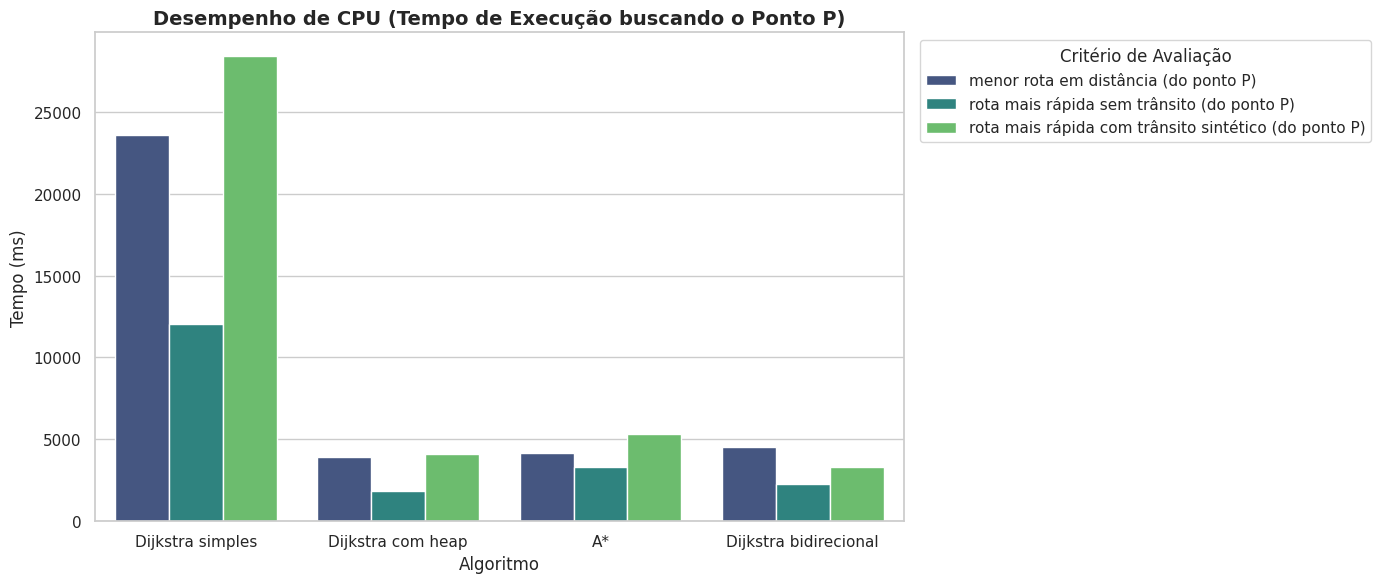

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando um estilo limpo e profissional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_resultados_consolidados,
    x='algoritmo',
    y='tempo_execucao_ms_com_P',
    hue='criterio',
    palette='viridis'
)

plt.title(
    'Desempenho de CPU (Tempo de Execução buscando o Ponto P)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Tempo (ms)', fontsize=12)
plt.xlabel('Algoritmo', fontsize=12)

# Legenda fora do gráfico
plt.legend(
    title='Critério de Avaliação',
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Análise da eficiência da busca

O gráfico abaixo apresenta a quantidade de nós expandidos por cada algoritmo durante a busca pelo ponto **P**, para os diferentes critérios de avaliação. Essa métrica representa o esforço realizado pelo algoritmo para encontrar uma solução, permitindo comparar a eficiência das estratégias de busca independentemente do tempo de execução.

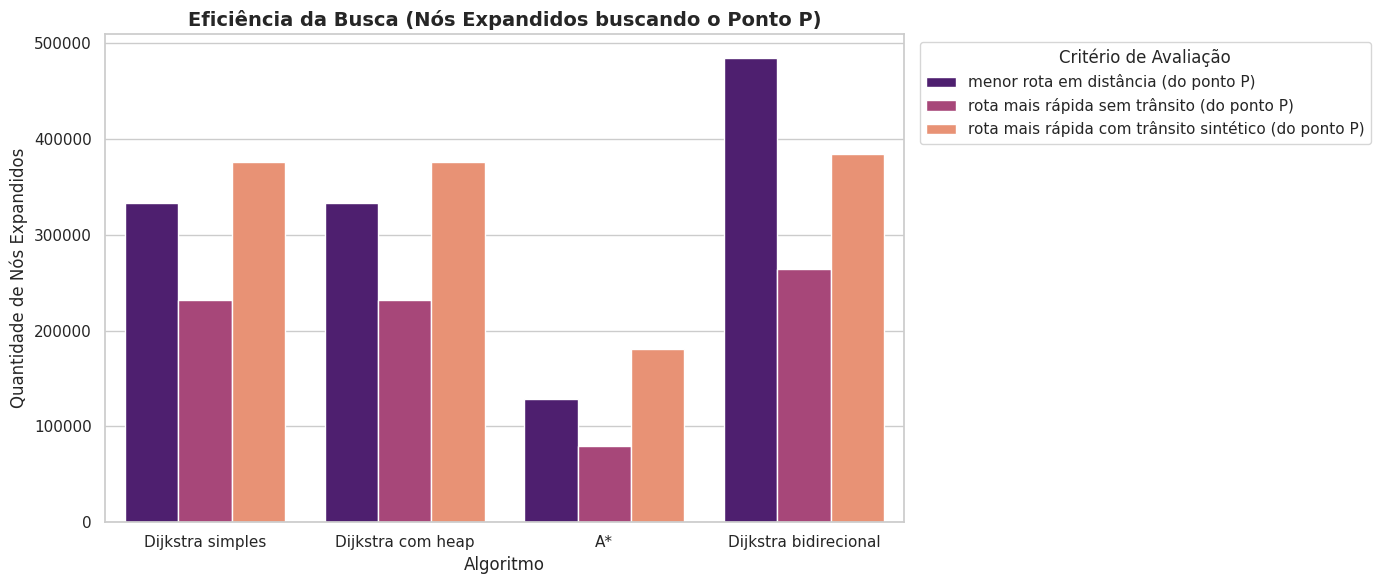

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando um estilo limpo e profissional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_resultados_consolidados,
    x='algoritmo',
    y='nos_expandidos_com_P',
    hue='criterio',
    palette='magma'
)

plt.title(
    'Eficiência da Busca (Nós Expandidos buscando o Ponto P)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Quantidade de Nós Expandidos', fontsize=12)
plt.xlabel('Algoritmo', fontsize=12)

# Legenda fora do gráfico
plt.legend(
    title='Critério de Avaliação',
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Ganho percentual obtido pela caminhada

O gráfico apresenta o ganho percentual obtido após permitir que o usuário caminhe até o ponto de embarque selecionado. Valores positivos indicam redução do custo total da viagem, enquanto valores negativos representam aumento do custo em relação ao embarque imediato.

/tmp/ipykernel_2738/789535509.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


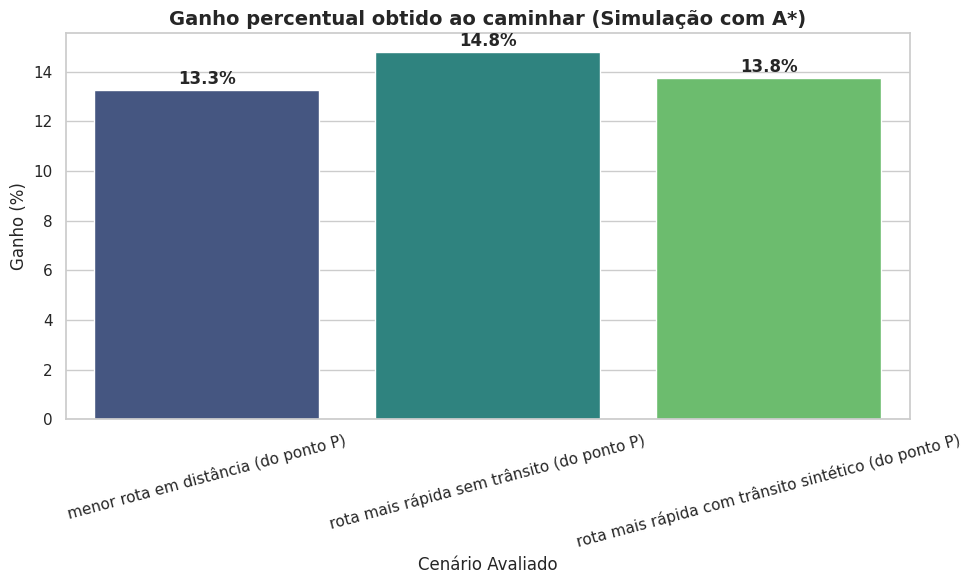

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Filtramos o DataFrame para manter apenas UM algoritmo (ex: A*)
df_filtrado = df_ganho_ao_caminhar[df_ganho_ao_caminhar['algoritmo'] == 'A*']

# Podemos reduzir um pouco a largura da figura, já que agora temos menos barras
plt.figure(figsize=(10, 6))

# 2. Trocamos o eixo X para ser o 'criterio' e removemos o 'hue'
sns.barplot(
    data=df_filtrado,
    x="criterio",
    y="ganho_percentual",
    palette="viridis"
)

plt.title("Ganho percentual obtido ao caminhar (Simulação com A*)", fontsize=14, fontweight='bold')
plt.xlabel("Cenário Avaliado", fontsize=12)
plt.ylabel("Ganho (%)", fontsize=12)

# Adicionamos os valores exatos em cima de cada barra para facilitar a leitura
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontweight='bold')

# Como os nomes dos critérios costumam ser longos, rotacionamos os textos do eixo X
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Análise do impacto da caminhada no tempo total de viagem

Nesta análise é avaliado o impacto da utilização de um ponto intermediário de embarque/desembarque (P) no tempo total de deslocamento.
O algoritmo **A\*** é utilizado para encontrar a rota mais rápida considerando dois cenários distintos: uma rede viária sem congestionamento e uma rede com trânsito sintético aplicado.

O gráfico compara três componentes do deslocamento:

- **Trajeto completo de carro:** representa o tempo necessário para realizar toda a viagem utilizando apenas o veículo desde a origem até o destino.
- **Trecho de carro a partir do ponto P:** representa o deslocamento realizado após o usuário caminhar até o ponto intermediário.
- **Trecho a pé até P:** corresponde ao tempo adicional gasto no deslocamento inicial caminhando.

O objetivo é observar se a combinação entre caminhada e transporte motorizado pode reduzir o tempo total da viagem em comparação ao trajeto convencional realizado exclusivamente de carro. Além disso, é analisada a influência do congestionamento no comportamento das rotas encontradas pelo algoritmo.

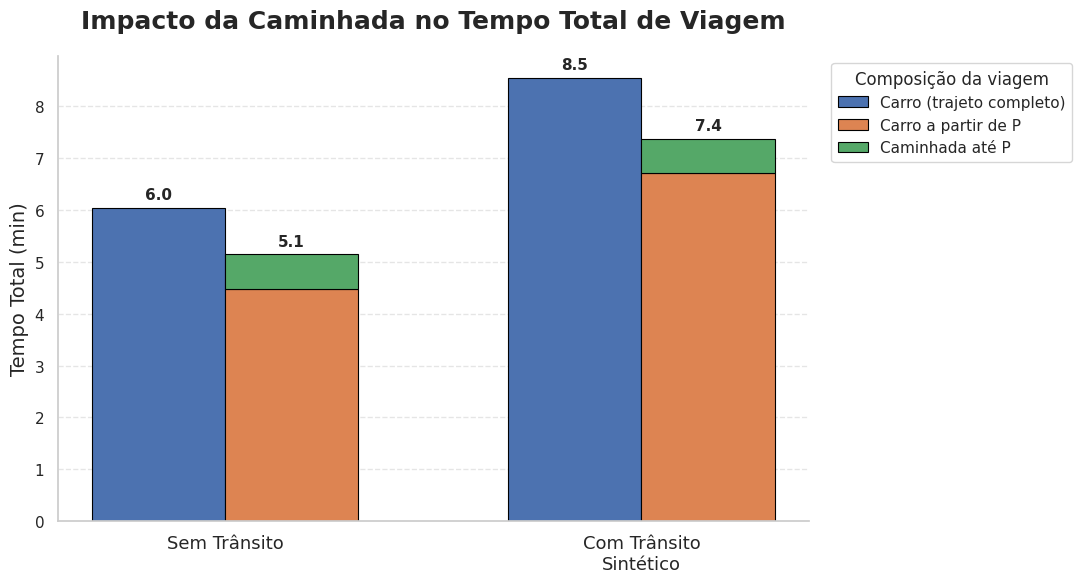

In [257]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(
    style="whitegrid",
)

# 1. Filtrar apenas A*
df_astar = df_resultados_consolidados[
    df_resultados_consolidados['algoritmo'] == 'A*'
].copy()

criterios_tempo = [
    'rota mais rápida sem trânsito (do ponto P)',
    'rota mais rápida com trânsito sintético (do ponto P)'
]

labels_cenarios = [
    'Sem Trânsito',
    'Com Trânsito\nSintético'
]

drive_sem_caminhada = []
drive_com_caminhada = []
walk_com_caminhada = []

for crit in criterios_tempo:
    linha = df_astar[df_astar['criterio'] == crit].iloc[0]

    drive_sem_caminhada.append(
        linha['custo_sem_caminhada'] / 60.0
    )

    drive_com_caminhada.append(
        linha['T_drive_P_B_min']
    )

    walk_com_caminhada.append(
        linha['T_walk_min']
    )


# ============================
# Gráfico
# ============================

x = np.arange(len(labels_cenarios))
width = 0.32


fig, ax = plt.subplots(figsize=(11, 6))


# Paleta Seaborn
cores = sns.color_palette("deep")


# Barra sem caminhada
b1 = ax.bar(
    x - width/2,
    drive_sem_caminhada,
    width,
    label="Carro (trajeto completo)",
    color=cores[0],
    edgecolor="black",
    linewidth=0.8
)


# Barra com caminhada
b2 = ax.bar(
    x + width/2,
    drive_com_caminhada,
    width,
    label="Carro a partir de P",
    color=cores[1],
    edgecolor="black",
    linewidth=0.8
)


b3 = ax.bar(
    x + width/2,
    walk_com_caminhada,
    width,
    bottom=drive_com_caminhada,
    label="Caminhada até P",
    color=cores[2],
    edgecolor="black",
    linewidth=0.8
)


# ============================
# Formatação
# ============================

ax.set_title(
    "Impacto da Caminhada no Tempo Total de Viagem",
    fontsize=18,
    weight="bold",
    pad=20
)

ax.set_ylabel(
    "Tempo Total (min)",
    fontsize=14
)

ax.set_xticks(x)
ax.set_xticklabels(
    labels_cenarios,
    fontsize=13
)


# Grade mais suave
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

ax.grid(axis="x", visible=False)


# Remove bordas
sns.despine(
    top=True,
    right=True
)


# Legenda melhor posicionada
ax.legend(
    title="Composição da viagem",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)


# Valores em cima das barras
ax.bar_label(
    b1,
    fmt="%.1f",
    padding=4,
    fontsize=11,
    fontweight="bold"
)

ax.bar_label(
    b3,
    labels=[
        f"{d+w:.1f}"
        for d,w in zip(drive_com_caminhada, walk_com_caminhada)
    ],
    padding=4,
    fontsize=11,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

## 26. Mapa final com todos os filtros

O mapa final está organizado em dois blocos principais:

- **Casos com caminhada**: o passageiro caminha de **A** até um ponto **P**, e o carro segue de **P** até **B**;
- **Caso sem caminhada (A = P)**: o passageiro não caminha, então o ponto de embarque é o próprio **A**.

Em cada bloco existem três tipos de rota:

- rota mais rápida sem trânsito;
- rota mais rápida com trânsito sintético;
- menor rota em distância.

No cenário com trânsito, o peso `traffic_time` usa o trânsito sintético aplicado sobre trechos da rota rápida sem trânsito usada como referência. Assim, o mapa permite comparar a rota normal com a rota após penalização de congestionamento.

Esta célula não recalcula os caminhos. Ela apenas organiza, em grupos de filtros, os resultados já calculados nas células dos algoritmos. Cada camada do mapa recebe:

- nome do algoritmo;
- critério de custo;
- caminho a pé, quando houver caminhada;
- conexão curta até o ponto de embarque na malha de carro;
- rota de carro até o destino.

Para evitar confusão visual, a cor vermelha fica reservada para as vias penalizadas pelo trânsito sintético. As rotas dos filtros usam uma paleta própria, com cores diferentes entre si.

O objetivo é permitir comparar visualmente, no mesmo mapa, as escolhas feitas por cada algoritmo e por cada peso.

In [258]:
solucoes_mapa = {
    "Casos com caminhada": [
        ("Dijkstra simples", "rota mais rápida sem trânsito (do ponto P)", melhor_dijkstra_simples_tempo_sem, True),
        ("Dijkstra simples", "rota mais rápida com trânsito sintético (do ponto P)", melhor_dijkstra_simples_tempo_com, False),
        ("Dijkstra simples", "menor rota em distância (do ponto P)", melhor_dijkstra_simples_distancia, False),
        ("Dijkstra com heap", "rota mais rápida sem trânsito (do ponto P)", melhor_dijkstra_heap_tempo_sem, False),
        ("Dijkstra com heap", "rota mais rápida com trânsito sintético (do ponto P)", melhor_dijkstra_heap_tempo_com, False),
        ("Dijkstra com heap", "menor rota em distância (do ponto P)", melhor_dijkstra_heap_distancia, False),
        ("A*", "rota mais rápida sem trânsito (do ponto P)", melhor_astar_tempo_sem, False),
        ("A*", "rota mais rápida com trânsito sintético (do ponto P)", melhor_astar_tempo_com, False),
        ("A*", "menor rota em distância (do ponto P)", melhor_astar_distancia, False),
        ("Dijkstra bidirecional", "rota mais rápida sem trânsito (do ponto P)", melhor_bidirecional_tempo_sem, False),
        ("Dijkstra bidirecional", "rota mais rápida com trânsito sintético (do ponto P)", melhor_bidirecional_tempo_com, False),
        ("Dijkstra bidirecional", "menor rota em distância (do ponto P)", melhor_bidirecional_distancia, False),
    ],
    "Caso sem caminhada (A = P)": [
        ("Dijkstra simples", "rota mais rápida sem trânsito (do ponto A)", sem_dijkstra_simples_tempo_sem, False),
        ("Dijkstra simples", "rota mais rápida com trânsito sintético (do ponto A)", sem_dijkstra_simples_tempo_com, False),
        ("Dijkstra simples", "menor rota em distância (do ponto A)", sem_dijkstra_simples_distancia, False),
        ("Dijkstra com heap", "rota mais rápida sem trânsito (do ponto A)", sem_dijkstra_heap_tempo_sem, False),
        ("Dijkstra com heap", "rota mais rápida com trânsito sintético (do ponto A)", sem_dijkstra_heap_tempo_com, False),
        ("Dijkstra com heap", "menor rota em distância (do ponto A)", sem_dijkstra_heap_distancia, False),
        ("A*", "rota mais rápida sem trânsito (do ponto A)", sem_astar_tempo_sem, False),
        ("A*", "rota mais rápida com trânsito sintético (do ponto A)", sem_astar_tempo_com, False),
        ("A*", "menor rota em distância (do ponto A)", sem_astar_distancia, False),
        ("Dijkstra bidirecional", "rota mais rápida sem trânsito (do ponto A)", sem_bidirecional_tempo_sem, False),
        ("Dijkstra bidirecional", "rota mais rápida com trânsito sintético (do ponto A)", sem_bidirecional_tempo_com, False),
        ("Dijkstra bidirecional", "menor rota em distância (do ponto A)", sem_bidirecional_distancia, False),
    ],
}

mapa_consolidado = montar_mapa_consolidado(solucoes_mapa)

Mapa consolidado salvo em: saidas_ridesmart_aed2/mapa_consolidado_ridesmart_aed2.html


## 27. Validação automática das rotas

Esta célula verifica se as camadas principais fazem sentido estruturalmente.

Ela testa se:

- a rota de carro termina em **B**;
- o caso sem caminhada usa **A** como ponto de embarque;
- os casos com caminhada possuem caminho a pé de **A** até **P**;
- os custos calculados são finitos.

Se algum filtro estiver inconsistente, a célula gera erro.

Essa validação não prova que a rota é a melhor matematicamente, porque isso já é responsabilidade dos algoritmos implementados. O papel dela é detectar problemas de integração, como uma camada vazia, uma rota que não termina em **B** ou um filtro de caminhada sem caminho a pé correspondente.

In [259]:
def validar_resultado_rota(nome, criterio, resultado):
    problemas = []
    rota_p_b = resultado.get("rota_P_B")

    if not rota_p_b:
        problemas.append("rota P->B vazia")
        return problemas

    if rota_p_b[-1] != B_direcao:
        problemas.append("rota P->B não termina em B")

    if resultado.get("P") == "A":
        if rota_p_b[0] != A_direcao:
            problemas.append("caso sem caminhada não começa em A")
    else:
        no_p_caminhada = int(resultado["no_caminhada"])
        try:
            nx.shortest_path(G_caminhada, A_caminhada, no_p_caminhada, weight="length")
        except Exception as exc:
            problemas.append(f"sem caminho a pé A->P: {type(exc).__name__}")

    if resultado.get("custo") is None or not math.isfinite(float(resultado["custo"])):
        problemas.append("custo inválido")

    return problemas


linhas_validacao = []
for grupo, itens in solucoes_mapa.items():
    for algoritmo, criterio, resultado, _ in itens:
        problemas = validar_resultado_rota(algoritmo, criterio, resultado)
        linhas_validacao.append({
            "grupo": grupo,
            "algoritmo": algoritmo,
            "criterio": criterio,
            "P": resultado.get("P"),
            "status": "OK" if not problemas else "ERRO",
            "problemas": "; ".join(problemas),
        })

df_validacao_rotas = pd.DataFrame(linhas_validacao)
display(df_validacao_rotas)

if (df_validacao_rotas["status"] != "OK").any():
    raise AssertionError("Algumas camadas/filtros têm problemas de rota.")

print("VALIDACAO_FILTROS_OK")

,grupo,algoritmo,criterio,P,status,problemas
0,Casos com caminhada,Dijkstra simples,rota mais rápida sem trânsito (do ponto P),P2,OK,
1,Casos com caminhada,Dijkstra simples,rota mais rápida com trânsito sintético (do po...,P2,OK,
2,Casos com caminhada,Dijkstra simples,menor rota em distância (do ponto P),P9,OK,
3,Casos com caminhada,Dijkstra com heap,rota mais rápida sem trânsito (do ponto P),P2,OK,
4,Casos com caminhada,Dijkstra com heap,rota mais rápida com trânsito sintético (do po...,P2,OK,
5,Casos com caminhada,Dijkstra com heap,menor rota em distância (do ponto P),P9,OK,
6,Casos com caminhada,A*,rota mais rápida sem trânsito (do ponto P),P2,OK,
7,Casos com caminhada,A*,rota mais rápida com trânsito sintético (do po...,P2,OK,
8,Casos com caminhada,A*,menor rota em distância (do ponto P),P9,OK,
9,Casos com caminhada,Dijkstra bidirecional,rota mais rápida sem trânsito (do ponto P),P2,OK,


VALIDACAO_FILTROS_OK


## 28. Fechamento

Este notebook resolve o modelo do enunciado sem incluir posição inicial do veículo antes do embarque.

A modelagem final é:

```text
A -> P: caminhada
P -> B: carro
```

O ponto **P** é escolhido entre candidatos alcançáveis a pé dentro de **X** e próximos da malha viária. O ícone de carro no mapa mostra exatamente onde ocorre o embarque na rede de veículos.

As tabelas e o mapa final permitem comparar algoritmos, pesos, trânsito sintético, caso sem caminhada e ganho ao caminhar.